In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

## Load dataset

In [2]:
data = pd.read_csv('../M1_final.csv')

### Create the target variable and drop the delay column

In [3]:
# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28820 entries, 0 to 28819
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28820 non-null  int64  
 1   DAY_OF_MONTH       28820 non-null  int64  
 2   DAY_OF_WEEK        28820 non-null  int64  
 3   OP_UNIQUE_CARRIER  28820 non-null  object 
 4   TAIL_NUM           28820 non-null  object 
 5   DEST               28820 non-null  object 
 6   CRS_ELAPSED_TIME   28820 non-null  int64  
 7   DISTANCE           28820 non-null  int64  
 8   CRS_DEP_M          28820 non-null  int64  
 9   DEP_TIME_M         28820 non-null  int64  
 10  CRS_ARR_M          28820 non-null  int64  
 11  Temperature        28820 non-null  int64  
 12  Dew Point          28820 non-null  object 
 13  Humidity           28820 non-null  int64  
 14  Wind               28818 non-null  object 
 15  Wind Speed         28820 non-null  int64  
 16  Wind Gust          288

## Exploratory Data analysis

## 1. Dataset Overview and Basic Statistics

In [5]:
# Basic dataset information
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("📈 DATASET OVERVIEW")
print("="*50)
print(f"Dataset Shape: {data.shape}")
print(f"Total Flights: {len(data):,}")
print(f"Number of Features: {data.shape[1]-1}")  # Excluding target variable
print(f"Target Variable: is_delayed")

print(f"\n🎯 TARGET DISTRIBUTION")
print("="*30)
delay_counts = data['is_delayed'].value_counts()
delay_percentages = data['is_delayed'].value_counts(normalize=True) * 100

for i in [0, 1]:
    status = "On Time" if i == 0 else "Delayed"
    print(f"{status}: {delay_counts[i]:,} flights ({delay_percentages[i]:.1f}%)")

print(f"\n📊 BASIC STATISTICS")
print("="*30)
print(f"Missing Values: {data.isnull().sum().sum()}")
print(f"Duplicate Rows: {data.duplicated().sum()}")
print(f"Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📈 DATASET OVERVIEW
Dataset Shape: (28820, 23)
Total Flights: 28,820
Number of Features: 22
Target Variable: is_delayed

🎯 TARGET DISTRIBUTION
On Time: 24,799 flights (86.0%)
Delayed: 4,021 flights (14.0%)

📊 BASIC STATISTICS
Missing Values: 2
Duplicate Rows: 0
Memory Usage: 12.56 MB


In [6]:
# Detailed data types and unique values
print("📋 FEATURE DETAILS")
print("="*50)
print(f"{'Feature':<20} {'Type':<15} {'Unique Values':<15} {'Sample Values'}")
print("-" * 80)

for col in data.columns:
    dtype = str(data[col].dtype)
    unique_count = data[col].nunique()
    
    # Get sample values
    if data[col].dtype == 'object':
        sample_vals = list(data[col].unique()[:3])
    else:
        sample_vals = [data[col].min(), data[col].max()]
    
    sample_str = str(sample_vals)[:30] + "..." if len(str(sample_vals)) > 30 else str(sample_vals)
    
    print(f"{col:<20} {dtype:<15} {unique_count:<15} {sample_str}")

# Show first few rows
print(f"\n🔍 SAMPLE DATA")
print("="*30)
data.head()

📋 FEATURE DETAILS
Feature              Type            Unique Values   Sample Values
--------------------------------------------------------------------------------
MONTH                int64           3               [np.int64(1), np.int64(12)]
DAY_OF_MONTH         int64           31              [np.int64(1), np.int64(31)]
DAY_OF_WEEK          int64           7               [np.int64(1), np.int64(7)]
OP_UNIQUE_CARRIER    object          9               ['B6', 'DL', 'AA']
TAIL_NUM             object          2092            ['N828JB', 'N992JB', 'N959JB']
DEST                 object          65              ['CHS', 'LAX', 'FLL']
CRS_ELAPSED_TIME     int64           327             [np.int64(57), np.int64(697)]
DISTANCE             int64           64              [np.int64(94), np.int64(4983)]
CRS_DEP_M            int64           606             [np.int64(301), np.int64(1439)...
DEP_TIME_M           int64           1240            [np.int64(1), np.int64(1440)]
CRS_ARR_M            int

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,DEP_TIME_M,...,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT,is_delayed
0,11,1,5,B6,N828JB,CHS,124,636,324,323,...,58,W,25,38,29.86,Fair / Windy,9,17,14,0
1,11,1,5,B6,N992JB,LAX,371,2475,340,333,...,58,W,25,38,29.86,Fair / Windy,9,17,15,0
2,11,1,5,B6,N959JB,FLL,181,1069,301,341,...,58,W,25,38,29.86,Fair / Windy,9,17,22,1
3,11,1,5,B6,N999JQ,MCO,168,944,345,343,...,58,W,25,38,29.86,Fair / Windy,9,17,12,0
4,11,1,5,DL,N880DN,ATL,139,760,360,356,...,58,W,24,35,29.91,Fair / Windy,9,17,13,0


## 2. Target Variable Analysis

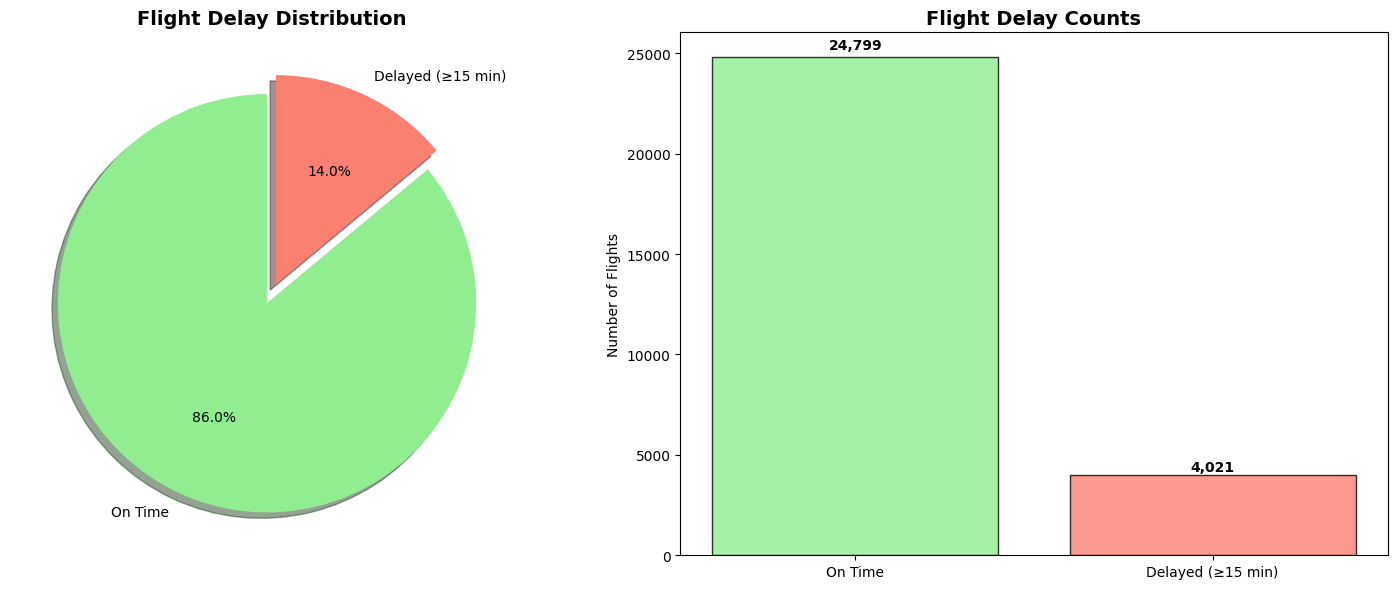

🎯 CLASS BALANCE ANALYSIS
Total Flights: 28,820
On Time: 24,799 (86.0%)
Delayed: 4,021 (14.0%)
Imbalance Ratio: 6.17:1
⚠️  Dataset is moderately imbalanced - consider using balanced class weights


In [7]:
# Target variable distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
delay_counts = data['is_delayed'].value_counts()
colors = ['lightgreen', 'salmon']
labels = ['On Time', 'Delayed (≥15 min)']
explode = (0.05, 0.05)

axes[0].pie(delay_counts.values, labels=labels, autopct='%1.1f%%', 
           colors=colors, explode=explode, shadow=True, startangle=90)
axes[0].set_title('Flight Delay Distribution', fontsize=14, fontweight='bold')

# Bar chart with counts
bars = axes[1].bar(labels, delay_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title('Flight Delay Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Flights')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Class balance analysis
print("🎯 CLASS BALANCE ANALYSIS")
print("="*40)
total_flights = len(data)
on_time = delay_counts[0]
delayed = delay_counts[1]

print(f"Total Flights: {total_flights:,}")
print(f"On Time: {on_time:,} ({on_time/total_flights*100:.1f}%)")
print(f"Delayed: {delayed:,} ({delayed/total_flights*100:.1f}%)")
print(f"Imbalance Ratio: {on_time/delayed:.2f}:1")

if delayed/total_flights < 0.4:
    print("⚠️  Dataset is moderately imbalanced - consider using balanced class weights")
else:
    print("✅ Dataset is reasonably balanced")

## 3. Temporal Patterns Analysis

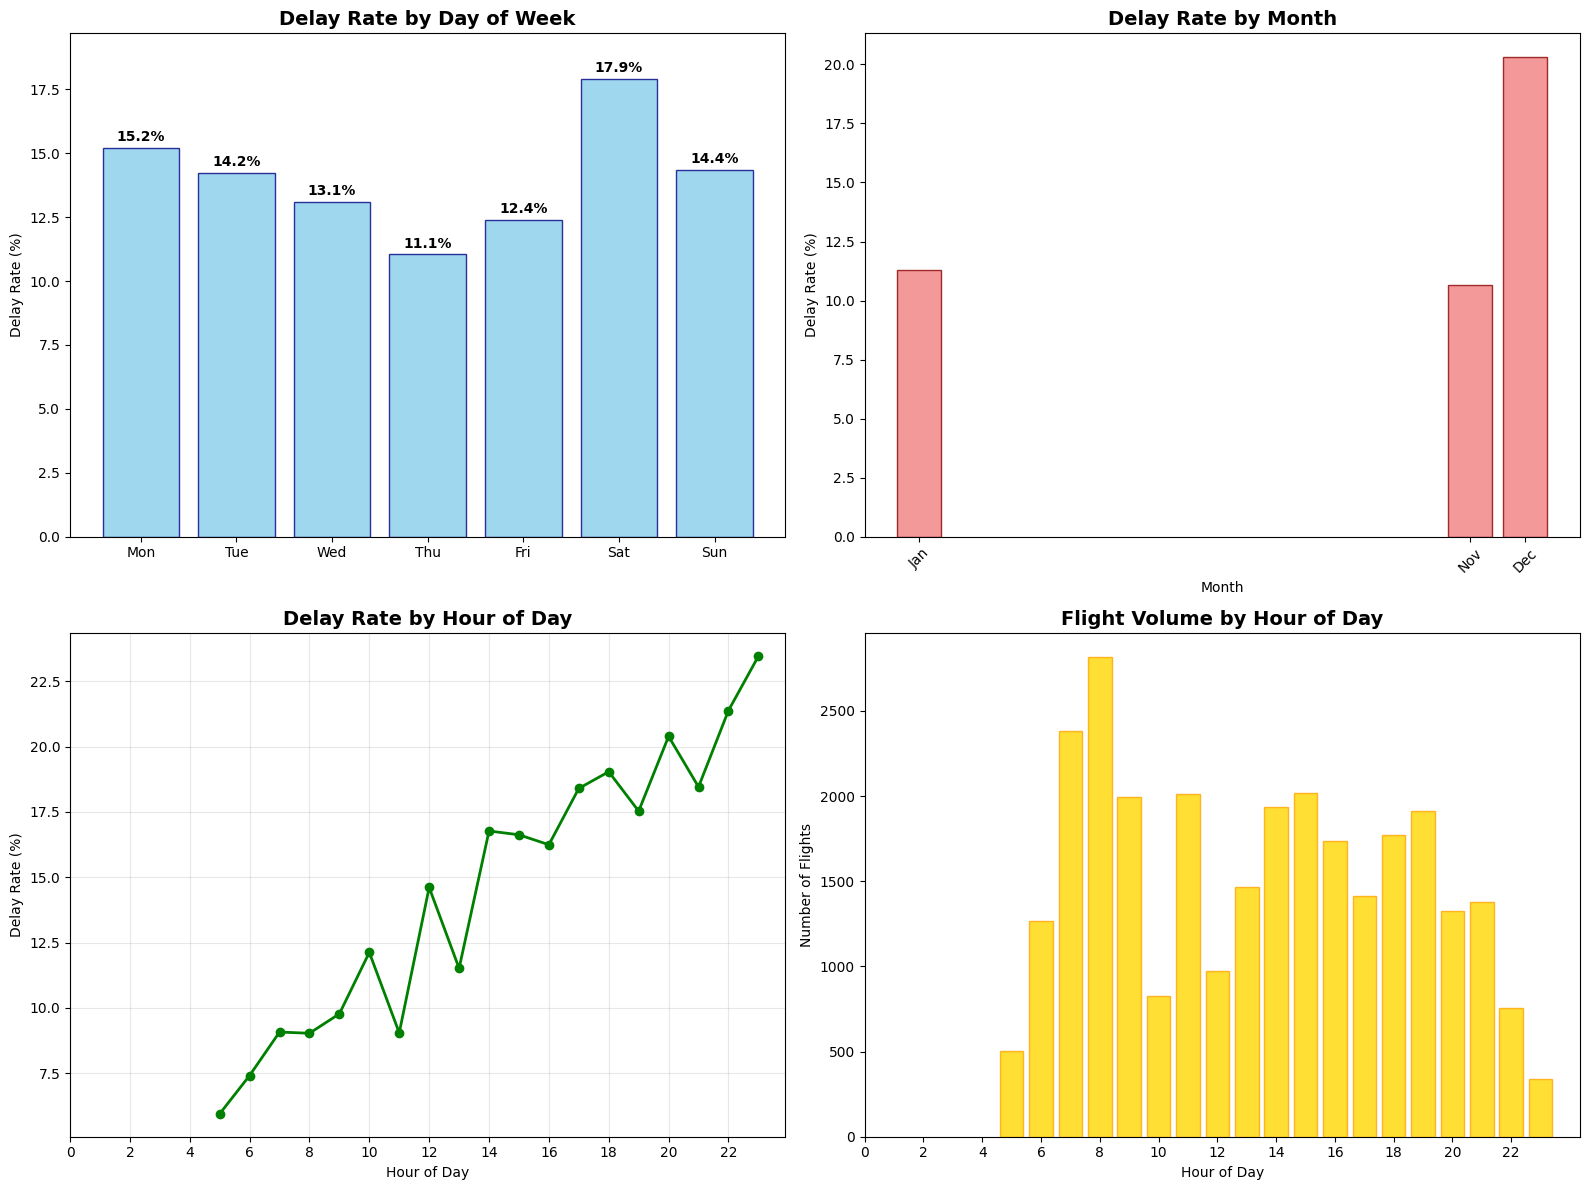

⏰ TEMPORAL INSIGHTS
🔸 Highest delay rate by day: Sat (17.9%)
🔸 Highest delay rate by month: Dec (20.3%)
🔸 Highest delay rate by hour: 23:00 (23.5%)
🔸 Rush hour delay rate: 14.6% vs Non-rush: 14.6%


In [8]:
# Time-based delay analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Delay rate by day of week
dow_delay = data.groupby('DAY_OF_WEEK')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
dow_delay['delay_rate'] = dow_delay['mean'] * 100
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_delay['day_name'] = [day_names[i-1] for i in dow_delay['DAY_OF_WEEK']]

bars1 = axes[0,0].bar(dow_delay['day_name'], dow_delay['delay_rate'], 
                      color='skyblue', alpha=0.8, edgecolor='navy')
axes[0,0].set_title('Delay Rate by Day of Week', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Delay Rate (%)')
axes[0,0].set_ylim(0, max(dow_delay['delay_rate']) * 1.1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Delay rate by month
month_delay = data.groupby('MONTH')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
month_delay['delay_rate'] = month_delay['mean'] * 100
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Use actual month numbers from the data instead of range(1,13)
bars2 = axes[0,1].bar(month_delay['MONTH'], month_delay['delay_rate'], 
                      color='lightcoral', alpha=0.8, edgecolor='darkred')
axes[0,1].set_title('Delay Rate by Month', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Delay Rate (%)')
axes[0,1].set_xlabel('Month')
axes[0,1].set_xticks(month_delay['MONTH'])
axes[0,1].set_xticklabels([month_names[i-1] for i in month_delay['MONTH']], rotation=45)

# 3. Delay rate by hour (convert minutes to hours)
data['hour'] = data['CRS_DEP_M'] // 60
hourly_delay = data.groupby('hour')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
hourly_delay['delay_rate'] = hourly_delay['mean'] * 100

axes[1,0].plot(hourly_delay['hour'], hourly_delay['delay_rate'], 
               marker='o', linewidth=2, markersize=6, color='green')
axes[1,0].set_title('Delay Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Delay Rate (%)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xticks(range(0, 24, 2))

# 4. Flight volume by hour
axes[1,1].bar(hourly_delay['hour'], hourly_delay['count'], 
              color='gold', alpha=0.8, edgecolor='orange')
axes[1,1].set_title('Flight Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Number of Flights')
axes[1,1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# Print insights
print("⏰ TEMPORAL INSIGHTS")
print("="*40)
peak_delay_dow = dow_delay.loc[dow_delay['delay_rate'].idxmax()]
peak_delay_month = month_delay.loc[month_delay['delay_rate'].idxmax()]
peak_delay_hour = hourly_delay.loc[hourly_delay['delay_rate'].idxmax()]

print(f"🔸 Highest delay rate by day: {peak_delay_dow['day_name']} ({peak_delay_dow['delay_rate']:.1f}%)")
print(f"🔸 Highest delay rate by month: {month_names[int(peak_delay_month['MONTH'])-1]} ({peak_delay_month['delay_rate']:.1f}%)")
print(f"🔸 Highest delay rate by hour: {int(peak_delay_hour['hour'])}:00 ({peak_delay_hour['delay_rate']:.1f}%)")

# Rush hour analysis
rush_hours = [7, 8, 17, 18, 19]
rush_delay = hourly_delay[hourly_delay['hour'].isin(rush_hours)]['delay_rate'].mean()
non_rush_delay = hourly_delay[~hourly_delay['hour'].isin(rush_hours)]['delay_rate'].mean()
print(f"🔸 Rush hour delay rate: {rush_delay:.1f}% vs Non-rush: {non_rush_delay:.1f}%")

## 4. Airport and Airline Analysis

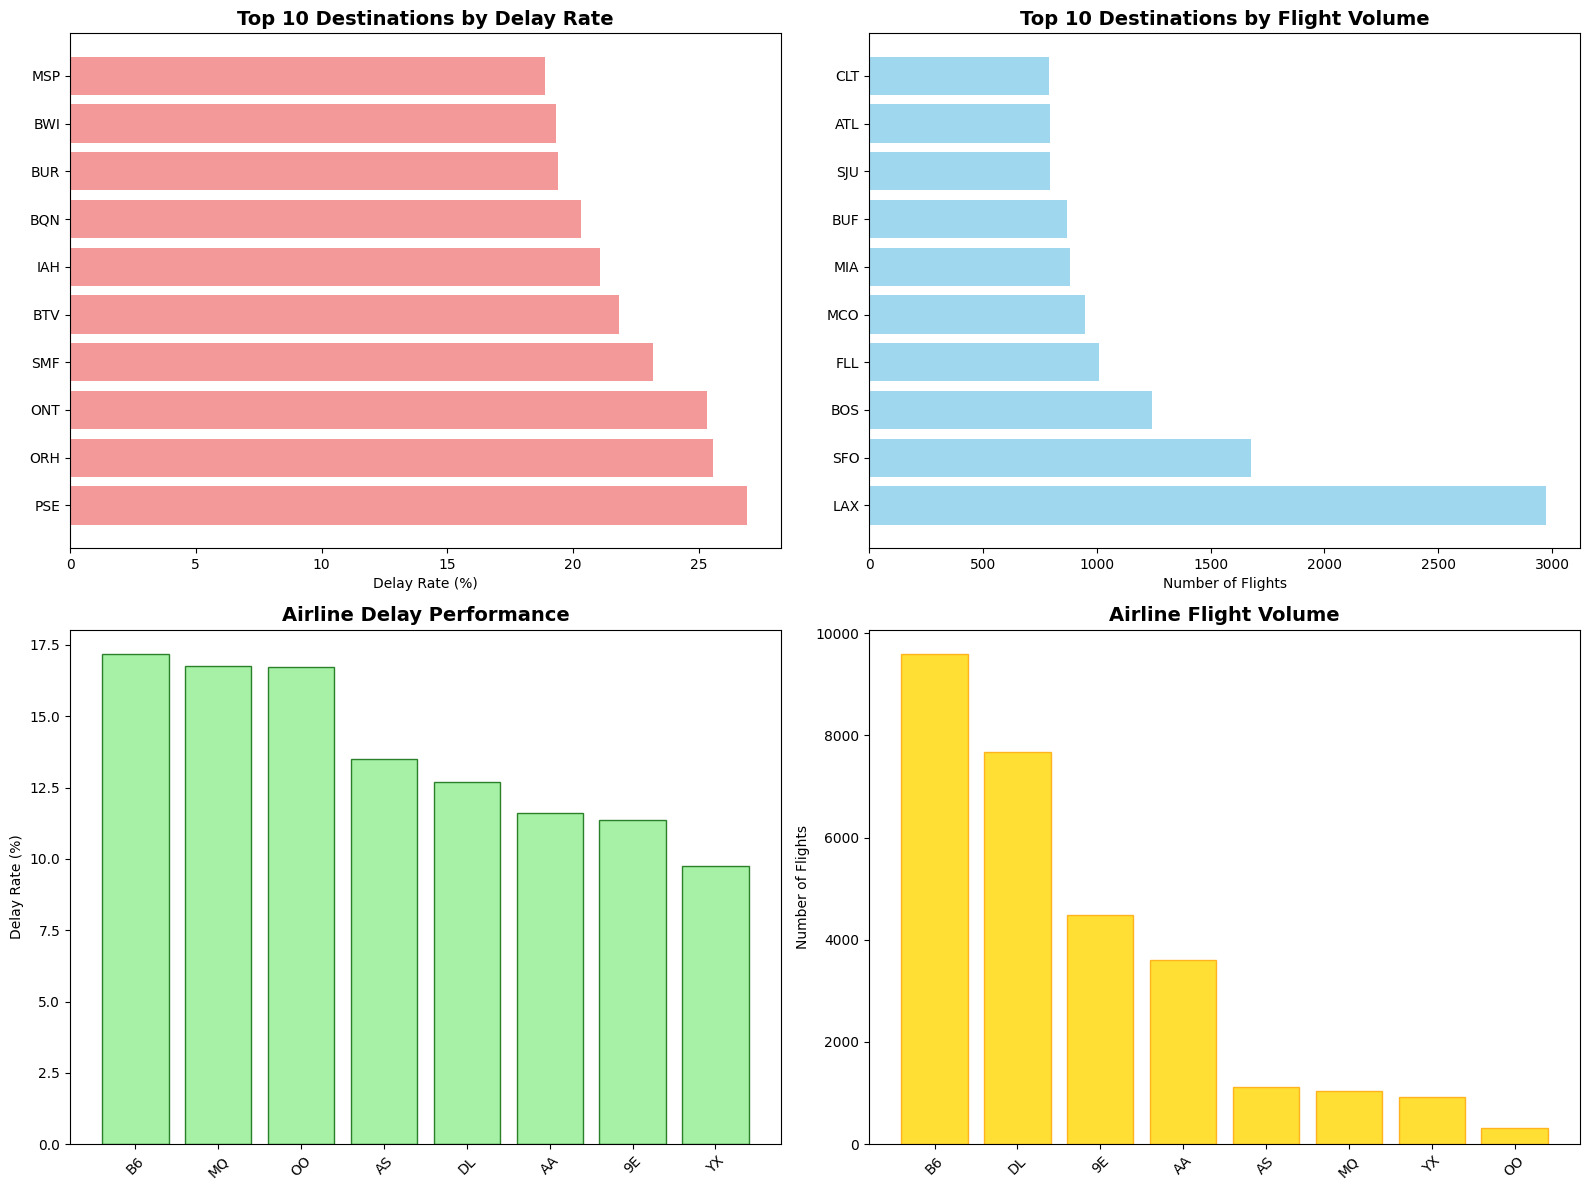

✈️ AIRPORT & AIRLINE INSIGHTS
🔸 Total unique destinations: 65
🔸 Total unique airlines: 9
🔸 Worst destination: PSE (26.9% delay rate)
🔸 Best airline: YX (9.7% delay rate)
🔸 Worst airline: B6 (17.2% delay rate)
🔸 Busiest destination: LAX (2,974 flights)
🔸 Busiest airline: B6 (9,589 flights)


In [9]:
# Airport and airline performance analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 destinations by delay rate
dest_stats = data.groupby('DEST')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
dest_stats = dest_stats[dest_stats['count'] >= 50]  # Filter for significant sample size
dest_stats['delay_rate'] = dest_stats['mean'] * 100
top_delay_dest = dest_stats.nlargest(10, 'delay_rate')

bars1 = axes[0,0].barh(range(len(top_delay_dest)), top_delay_dest['delay_rate'], 
                       color='lightcoral', alpha=0.8)
axes[0,0].set_yticks(range(len(top_delay_dest)))
axes[0,0].set_yticklabels(top_delay_dest['DEST'])
axes[0,0].set_xlabel('Delay Rate (%)')
axes[0,0].set_title('Top 10 Destinations by Delay Rate', fontsize=14, fontweight='bold')

# 2. Top 10 destinations by flight volume
top_volume_dest = dest_stats.nlargest(10, 'count')

bars2 = axes[0,1].barh(range(len(top_volume_dest)), top_volume_dest['count'], 
                       color='skyblue', alpha=0.8)
axes[0,1].set_yticks(range(len(top_volume_dest)))
axes[0,1].set_yticklabels(top_volume_dest['DEST'])
axes[0,1].set_xlabel('Number of Flights')
axes[0,1].set_title('Top 10 Destinations by Flight Volume', fontsize=14, fontweight='bold')

# 3. Airline performance
carrier_stats = data.groupby('OP_UNIQUE_CARRIER')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
carrier_stats = carrier_stats[carrier_stats['count'] >= 100]  # Filter for significant sample size
carrier_stats['delay_rate'] = carrier_stats['mean'] * 100
carrier_stats = carrier_stats.sort_values('delay_rate', ascending=False)

bars3 = axes[1,0].bar(range(len(carrier_stats)), carrier_stats['delay_rate'], 
                      color='lightgreen', alpha=0.8, edgecolor='darkgreen')
axes[1,0].set_xticks(range(len(carrier_stats)))
axes[1,0].set_xticklabels(carrier_stats['OP_UNIQUE_CARRIER'], rotation=45)
axes[1,0].set_ylabel('Delay Rate (%)')
axes[1,0].set_title('Airline Delay Performance', fontsize=14, fontweight='bold')

# 4. Carrier flight volume
carrier_volume = carrier_stats.sort_values('count', ascending=False)
bars4 = axes[1,1].bar(range(len(carrier_volume)), carrier_volume['count'], 
                      color='gold', alpha=0.8, edgecolor='orange')
axes[1,1].set_xticks(range(len(carrier_volume)))
axes[1,1].set_xticklabels(carrier_volume['OP_UNIQUE_CARRIER'], rotation=45)
axes[1,1].set_ylabel('Number of Flights')
axes[1,1].set_title('Airline Flight Volume', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
print("✈️ AIRPORT & AIRLINE INSIGHTS")
print("="*45)
print(f"🔸 Total unique destinations: {data['DEST'].nunique()}")
print(f"🔸 Total unique airlines: {data['OP_UNIQUE_CARRIER'].nunique()}")

worst_dest = top_delay_dest.iloc[0]
best_carrier = carrier_stats.iloc[-1]
worst_carrier = carrier_stats.iloc[0]

print(f"🔸 Worst destination: {worst_dest['DEST']} ({worst_dest['delay_rate']:.1f}% delay rate)")
print(f"🔸 Best airline: {best_carrier['OP_UNIQUE_CARRIER']} ({best_carrier['delay_rate']:.1f}% delay rate)")
print(f"🔸 Worst airline: {worst_carrier['OP_UNIQUE_CARRIER']} ({worst_carrier['delay_rate']:.1f}% delay rate)")

busiest_dest = top_volume_dest.iloc[0]
busiest_carrier = carrier_volume.iloc[0]
print(f"🔸 Busiest destination: {busiest_dest['DEST']} ({busiest_dest['count']:,} flights)")
print(f"🔸 Busiest airline: {busiest_carrier['OP_UNIQUE_CARRIER']} ({busiest_carrier['count']:,} flights)")

## 5. Weather Impact Analysis

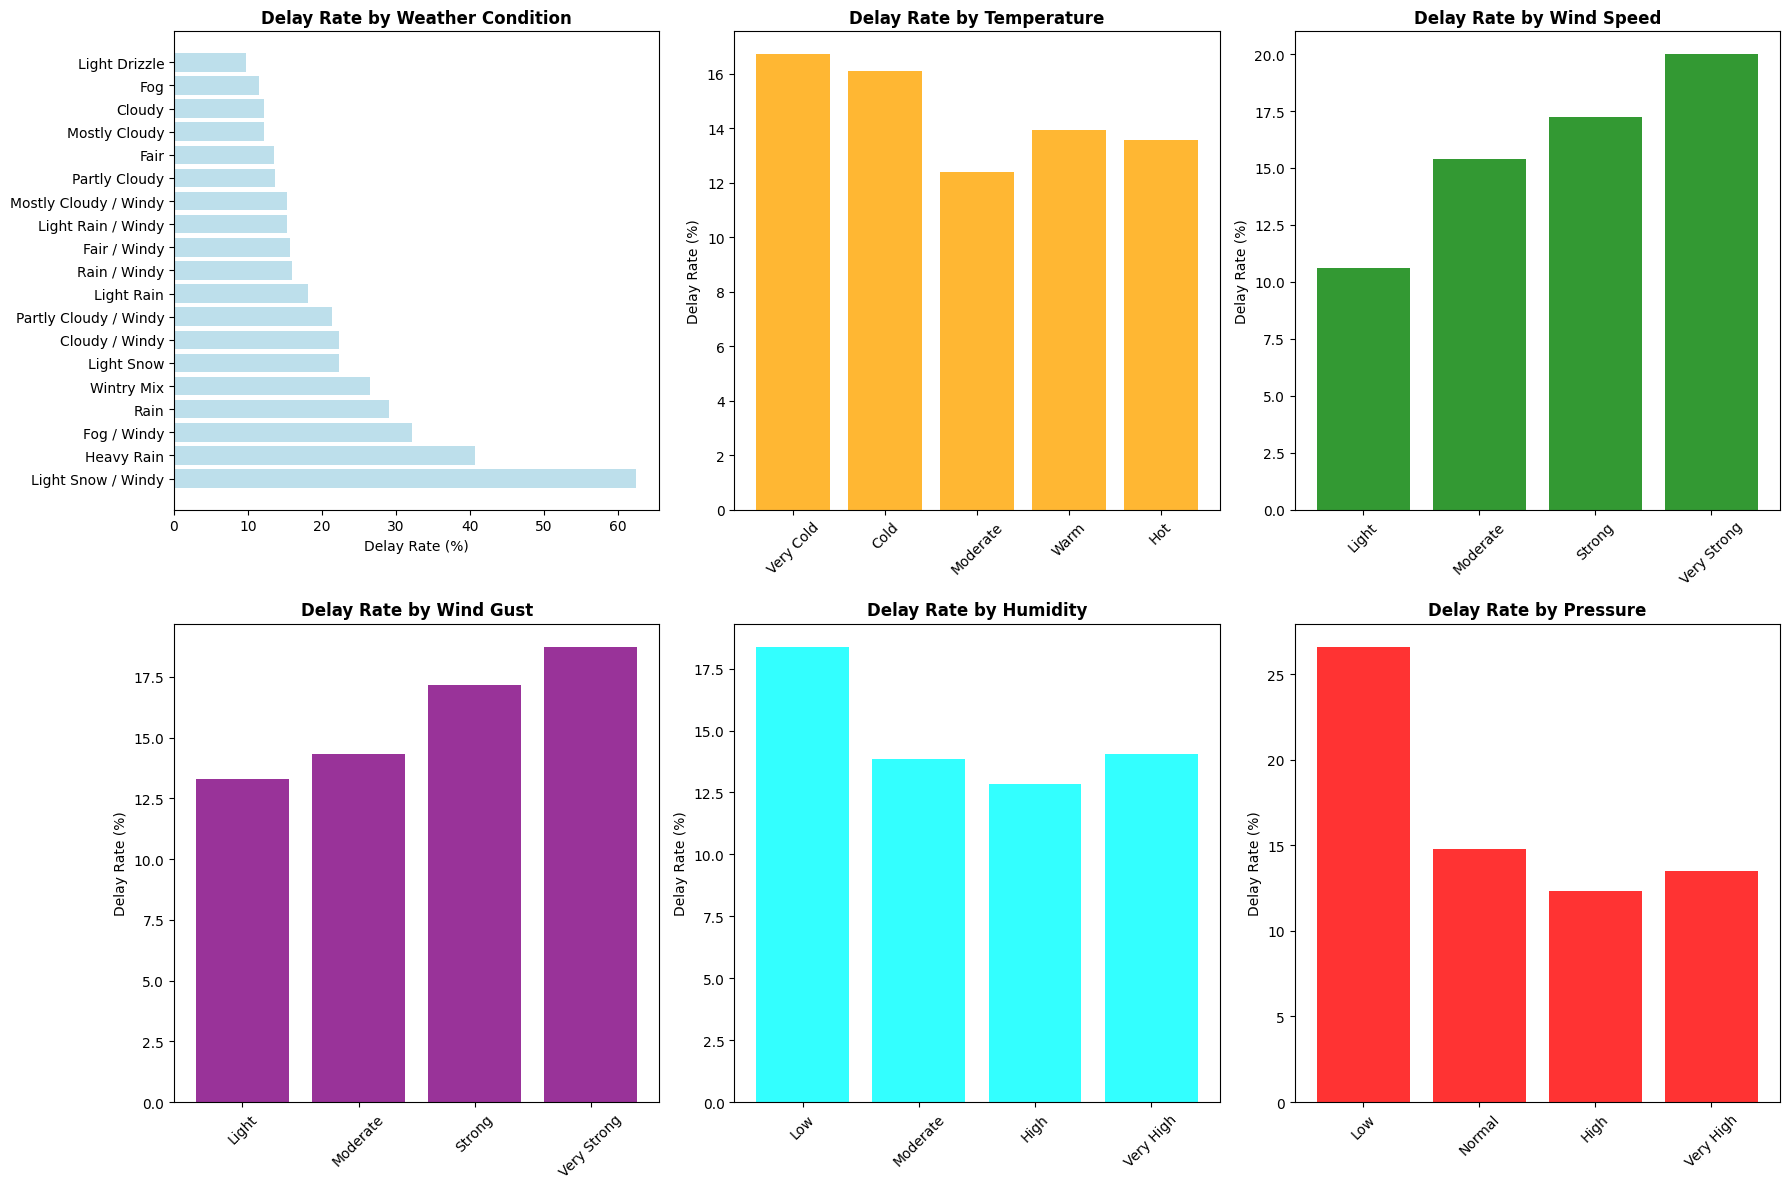

🌤️ WEATHER IMPACT INSIGHTS
Weather statistics for delayed vs on-time flights:
------------------------------------------------------------
Temperature : Delayed=  41.0 | On-time=  41.6 | Diff=  -0.6 ( -1.5%)
Wind Speed  : Delayed=  13.6 | On-time=  12.2 | Diff=  +1.4 (+11.8%)
Wind Gust   : Delayed=   6.8 | On-time=   5.3 | Diff=  +1.5 (+27.4%)
Humidity    : Delayed=  56.0 | On-time=  58.0 | Diff=  -2.0 ( -3.5%)
Pressure    : Delayed=  30.0 | On-time=  30.1 | Diff=  -0.1 ( -0.2%)

🔸 Worst weather condition: Light Snow / Windy (62.5% delay rate)
🔸 Best weather condition: Light Drizzle (9.8% delay rate)


In [10]:
# Weather conditions impact on delays
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Weather condition impact
condition_stats = data.groupby('Condition')['is_delayed'].agg(['count', 'sum', 'mean']).reset_index()
condition_stats = condition_stats[condition_stats['count'] >= 20]
condition_stats['delay_rate'] = condition_stats['mean'] * 100
condition_stats = condition_stats.sort_values('delay_rate', ascending=False)

bars1 = axes[0,0].barh(range(len(condition_stats)), condition_stats['delay_rate'], 
                       color='lightblue', alpha=0.8)
axes[0,0].set_yticks(range(len(condition_stats)))
axes[0,0].set_yticklabels(condition_stats['Condition'])
axes[0,0].set_xlabel('Delay Rate (%)')
axes[0,0].set_title('Delay Rate by Weather Condition', fontsize=12, fontweight='bold')

# 2. Temperature vs Delays
temp_bins = pd.cut(data['Temperature'], bins=5, labels=['Very Cold', 'Cold', 'Moderate', 'Warm', 'Hot'])
temp_delay = data.groupby(temp_bins)['is_delayed'].mean() * 100
axes[0,1].bar(temp_delay.index, temp_delay.values, color='orange', alpha=0.8)
axes[0,1].set_title('Delay Rate by Temperature', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Delay Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Wind Speed vs Delays
wind_bins = pd.cut(data['Wind Speed'], bins=4, labels=['Light', 'Moderate', 'Strong', 'Very Strong'])
wind_delay = data.groupby(wind_bins)['is_delayed'].mean() * 100
axes[0,2].bar(wind_delay.index, wind_delay.values, color='green', alpha=0.8)
axes[0,2].set_title('Delay Rate by Wind Speed', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Delay Rate (%)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Wind Gust vs Delays
gust_bins = pd.cut(data['Wind Gust'], bins=4, labels=['Light', 'Moderate', 'Strong', 'Very Strong'])
gust_delay = data.groupby(gust_bins)['is_delayed'].mean() * 100
axes[1,0].bar(gust_delay.index, gust_delay.values, color='purple', alpha=0.8)
axes[1,0].set_title('Delay Rate by Wind Gust', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Delay Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Humidity vs Delays
humid_bins = pd.cut(data['Humidity'], bins=4, labels=['Low', 'Moderate', 'High', 'Very High'])
humid_delay = data.groupby(humid_bins)['is_delayed'].mean() * 100
axes[1,1].bar(humid_delay.index, humid_delay.values, color='cyan', alpha=0.8)
axes[1,1].set_title('Delay Rate by Humidity', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Delay Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Pressure vs Delays
pressure_bins = pd.cut(data['Pressure'], bins=4, labels=['Low', 'Normal', 'High', 'Very High'])
pressure_delay = data.groupby(pressure_bins)['is_delayed'].mean() * 100
axes[1,2].bar(pressure_delay.index, pressure_delay.values, color='red', alpha=0.8)
axes[1,2].set_title('Delay Rate by Pressure', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('Delay Rate (%)')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Weather statistics
print("🌤️ WEATHER IMPACT INSIGHTS")
print("="*45)

numeric_weather_cols = ['Temperature', 'Wind Speed', 'Wind Gust', 'Humidity', 'Pressure']
print("Weather statistics for delayed vs on-time flights:")
print("-" * 60)

delayed_weather = data[data['is_delayed'] == 1][numeric_weather_cols].mean()
ontime_weather = data[data['is_delayed'] == 0][numeric_weather_cols].mean()

for col in numeric_weather_cols:
    delayed_val = delayed_weather[col]
    ontime_val = ontime_weather[col]
    diff = delayed_val - ontime_val
    diff_pct = (diff / ontime_val) * 100
    
    print(f"{col:12}: Delayed={delayed_val:6.1f} | On-time={ontime_val:6.1f} | Diff={diff:+6.1f} ({diff_pct:+5.1f}%)")

worst_condition = condition_stats.iloc[0]
best_condition = condition_stats.iloc[-1]
print(f"\n🔸 Worst weather condition: {worst_condition['Condition']} ({worst_condition['delay_rate']:.1f}% delay rate)")
print(f"🔸 Best weather condition: {best_condition['Condition']} ({best_condition['delay_rate']:.1f}% delay rate)")

## 6. Correlation Analysis

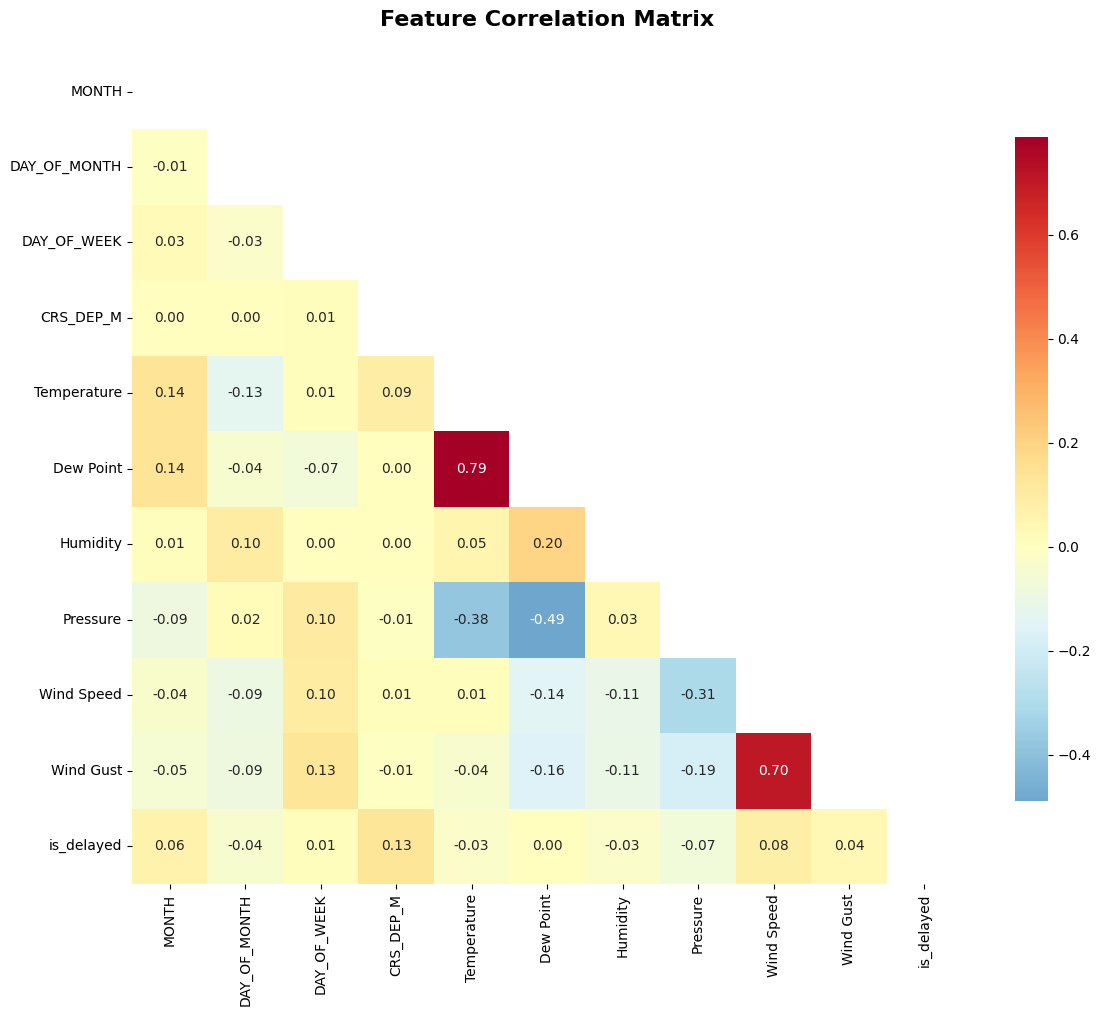

🔗 CORRELATION WITH DELAYS
Features most correlated with delays:
-----------------------------------
CRS_DEP_M       ↑ 0.126 (Moderate)
Wind Speed      ↑ 0.080 (Weak)
Pressure        ↓ 0.068 (Weak)
MONTH           ↑ 0.064 (Weak)
Wind Gust       ↑ 0.043 (Weak)
DAY_OF_MONTH    ↓ 0.037 (Weak)
Humidity        ↓ 0.030 (Weak)
Temperature     ↓ 0.027 (Weak)

⚠️  HIGH CORRELATION PAIRS (|r| > 0.7)
Temperature ↔ Dew Point: 0.788


In [11]:
# Correlation analysis between numeric features
numeric_cols = ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'CRS_DEP_M', 
                'Temperature', 'Dew Point', 'Humidity', 'Pressure', 'Wind Speed', 
                'Wind Gust', 'is_delayed']

# Create correlation matrix
corr_matrix = data[numeric_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target variable
target_corr = corr_matrix['is_delayed'].abs().sort_values(ascending=False)
target_corr = target_corr[target_corr.index != 'is_delayed']  # Remove self-correlation

print("🔗 CORRELATION WITH DELAYS")
print("="*40)
print("Features most correlated with delays:")
print("-" * 35)

for feature, corr_val in target_corr.head(8).items():
    direction = "↑" if corr_matrix['is_delayed'][feature] > 0 else "↓"
    strength = "Strong" if corr_val > 0.3 else "Moderate" if corr_val > 0.1 else "Weak"
    print(f"{feature:15} {direction} {corr_val:5.3f} ({strength})")

# Feature pairs with high correlation (multicollinearity check)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"\n⚠️  HIGH CORRELATION PAIRS (|r| > 0.7)")
    print("="*45)
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"{feat1} ↔ {feat2}: {corr_val:.3f}")
else:
    print("\n✅ No concerning multicollinearity detected (|r| > 0.7)")

## 7. Distribution Analysis

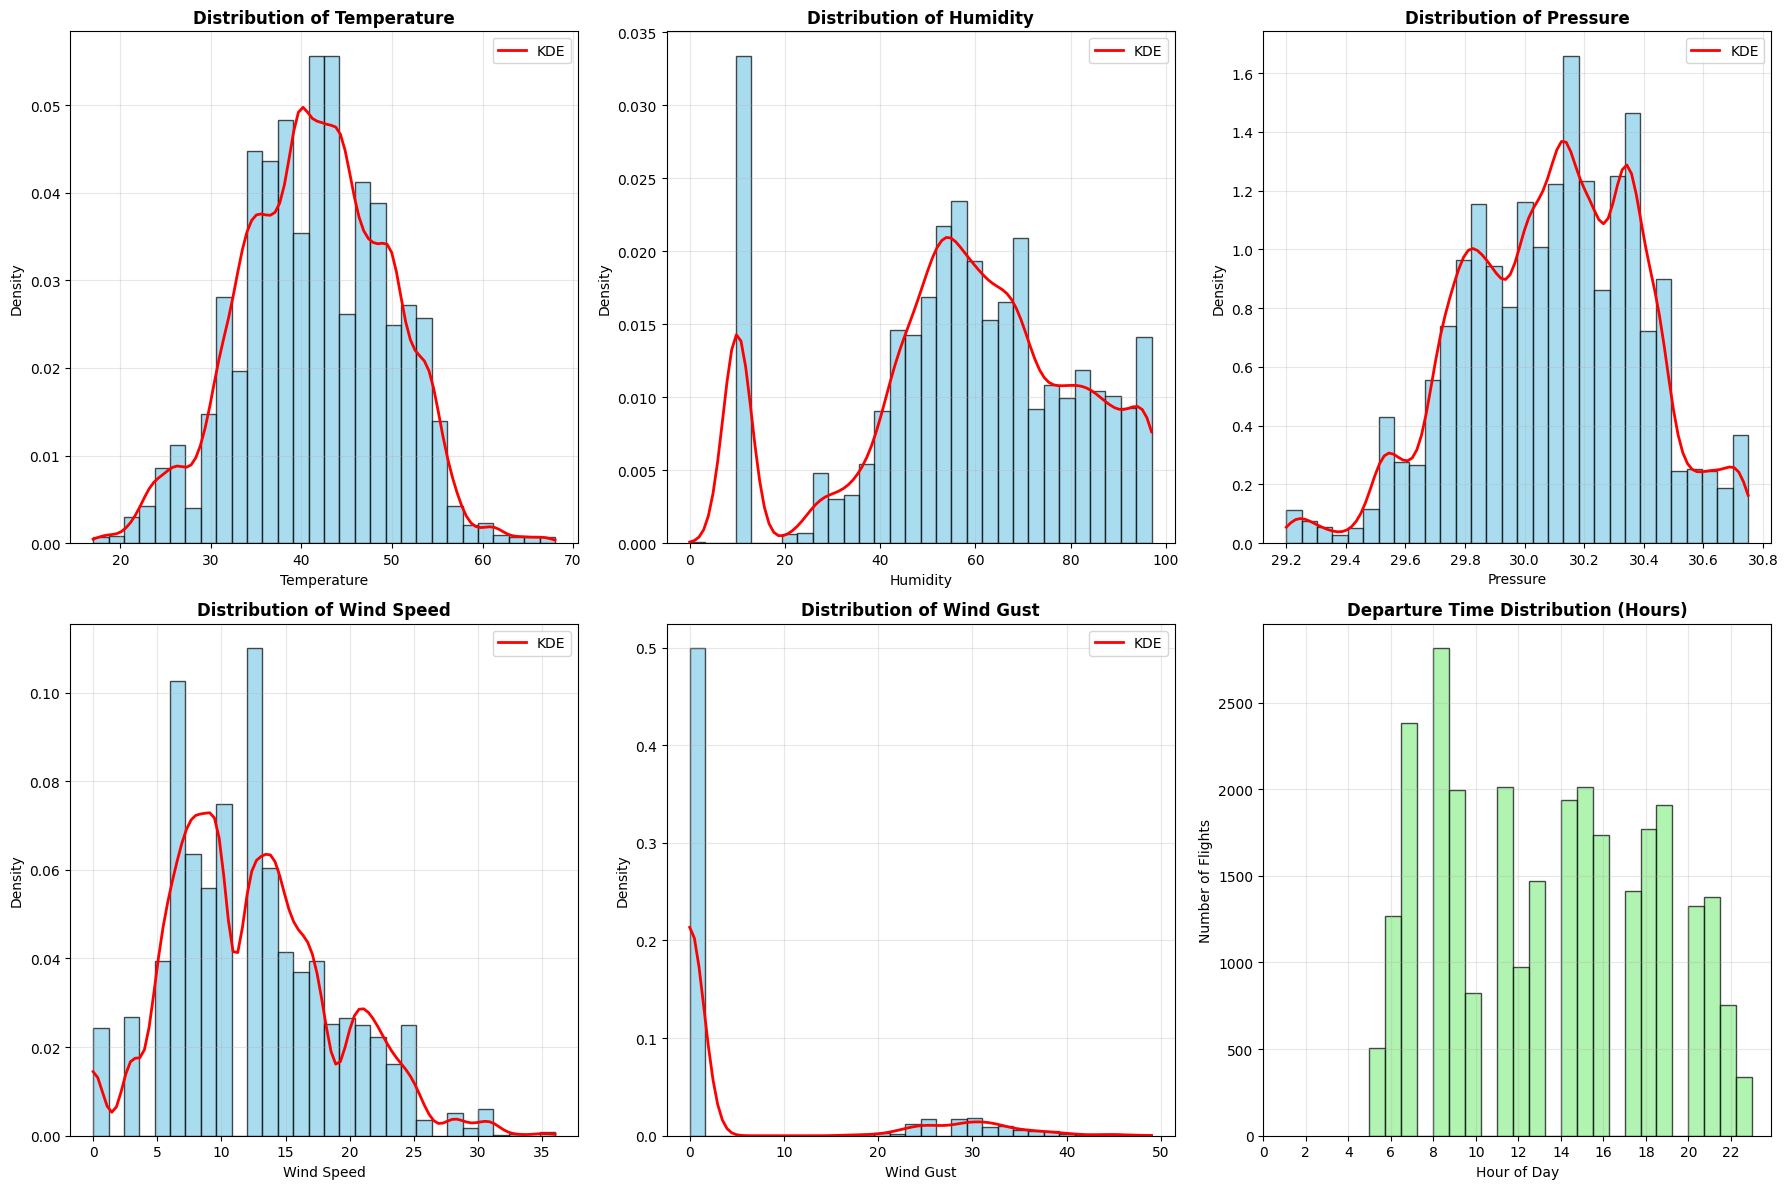

📊 DISTRIBUTION STATISTICS
Feature         Mean     Std      Min      Max      Skew    
-----------------------------------------------------------------
Temperature     41.5     8.0      17.0     68.0     -0.08   
Humidity        57.7     23.5     0.0      97.0     -0.48   
Pressure        30.1     0.3      29.2     30.8     -0.23   
Wind Speed      12.4     6.3      0.0      36.0     0.49    
Wind Gust       5.5      11.9     0.0      49.0     1.79    
CRS_DEP_M       831.0    299.4    301.0    1439.0   0.07    

🔍 OUTLIER ANALYSIS (IQR Method)
Temperature    : 178 outliers (0.6%)
Humidity       : 5 outliers (0.0%)
Pressure       : 32 outliers (0.1%)
Wind Speed     : 324 outliers (1.1%)
Wind Gust      : 5,313 outliers (18.4%)
   ⚠️  High outlier percentage - consider investigation


In [12]:
# Distribution analysis of key features
weather_features = ['Temperature', 'Humidity', 'Pressure', 'Wind Speed', 'Wind Gust']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(weather_features):
    # Histogram with KDE
    axes[i].hist(data[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Add KDE curve
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Departure time distribution
axes[5].hist(data['CRS_DEP_M'] // 60, bins=24, alpha=0.7, color='lightgreen', edgecolor='black')
axes[5].set_title('Departure Time Distribution (Hours)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Hour of Day')
axes[5].set_ylabel('Number of Flights')
axes[5].set_xticks(range(0, 24, 2))
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("📊 DISTRIBUTION STATISTICS")
print("="*50)
print(f"{'Feature':<15} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8} {'Skew':<8}")
print("-" * 65)

for feature in weather_features + ['CRS_DEP_M']:
    mean_val = data[feature].mean()
    std_val = data[feature].std()
    min_val = data[feature].min()
    max_val = data[feature].max()
    skew_val = data[feature].skew()
    
    print(f"{feature:<15} {mean_val:<8.1f} {std_val:<8.1f} {min_val:<8.1f} {max_val:<8.1f} {skew_val:<8.2f}")

# Outlier detection using IQR method
print(f"\n🔍 OUTLIER ANALYSIS (IQR Method)")
print("="*40)

for feature in weather_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    outlier_pct = len(outliers) / len(data) * 100
    
    print(f"{feature:<15}: {len(outliers):,} outliers ({outlier_pct:.1f}%)")
    if outlier_pct > 5:
        print(f"   ⚠️  High outlier percentage - consider investigation")

## 8. Advanced Pattern Analysis

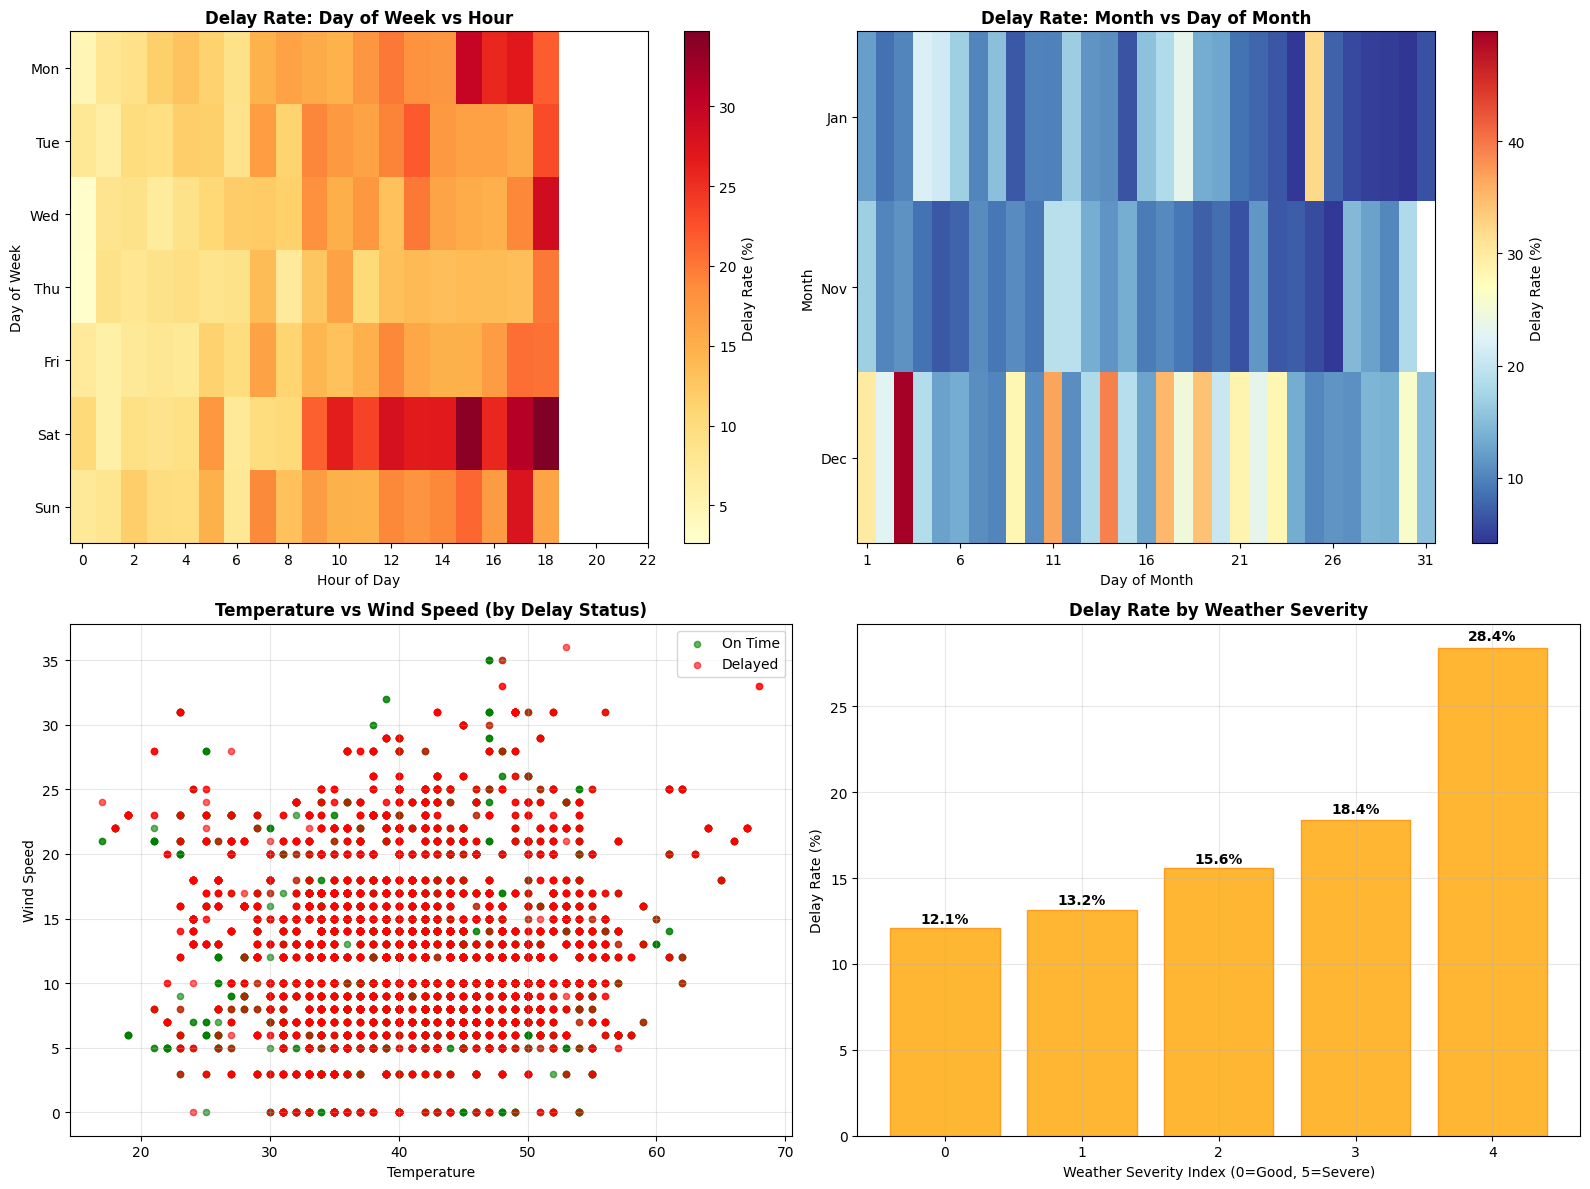

🔍 ADVANCED PATTERN INSIGHTS
🔸 Peak delay day: Saturday
🔸 Peak delay hour: 23:00
🔸 Peak delay rate: 34.7%
🔸 Severe weather delay rate: 23.4%
🔸 Good weather delay rate: 12.6%
🔸 Weather impact multiplier: 1.9x
🔸 Winter delay rate: 15.6%
🔸 Summer delay rate: nan%


In [13]:
# Advanced pattern analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap: Day of Week vs Hour delay patterns
data['hour'] = data['CRS_DEP_M'] // 60
pivot_hour_dow = data.pivot_table(values='is_delayed', index='DAY_OF_WEEK', 
                                  columns='hour', aggfunc='mean')
pivot_hour_dow = pivot_hour_dow * 100  # Convert to percentage

im1 = axes[0,0].imshow(pivot_hour_dow.values, cmap='YlOrRd', aspect='auto')
axes[0,0].set_yticks(range(len(pivot_hour_dow.index)))
axes[0,0].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0,0].set_xticks(range(0, 24, 2))
axes[0,0].set_xticklabels(range(0, 24, 2))
axes[0,0].set_title('Delay Rate: Day of Week vs Hour', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Day of Week')
plt.colorbar(im1, ax=axes[0,0], label='Delay Rate (%)')

# 2. Month vs Day of Month patterns
pivot_month_day = data.pivot_table(values='is_delayed', index='MONTH', 
                                   columns='DAY_OF_MONTH', aggfunc='mean')
pivot_month_day = pivot_month_day * 100

im2 = axes[0,1].imshow(pivot_month_day.values, cmap='RdYlBu_r', aspect='auto')
axes[0,1].set_yticks(range(len(pivot_month_day.index)))
# Get actual month names for the months present in the data
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
actual_month_labels = [month_names[int(month)-1] for month in pivot_month_day.index]
axes[0,1].set_yticklabels(actual_month_labels)
axes[0,1].set_xticks(range(0, 31, 5))
axes[0,1].set_xticklabels(range(1, 32, 5))
axes[0,1].set_title('Delay Rate: Month vs Day of Month', fontweight='bold')
axes[0,1].set_xlabel('Day of Month')
axes[0,1].set_ylabel('Month')
plt.colorbar(im2, ax=axes[0,1], label='Delay Rate (%)')

# 3. Temperature vs Wind Speed scatter (colored by delays)
delayed_flights = data[data['is_delayed'] == 1]
ontime_flights = data[data['is_delayed'] == 0]

# Sample data if too large for plotting
if len(data) > 10000:
    delayed_sample = delayed_flights.sample(min(5000, len(delayed_flights)))
    ontime_sample = ontime_flights.sample(min(5000, len(ontime_flights)))
else:
    delayed_sample = delayed_flights
    ontime_sample = ontime_flights

axes[1,0].scatter(ontime_sample['Temperature'], ontime_sample['Wind Speed'], 
                  alpha=0.6, c='green', label='On Time', s=20)
axes[1,0].scatter(delayed_sample['Temperature'], delayed_sample['Wind Speed'], 
                  alpha=0.6, c='red', label='Delayed', s=20)
axes[1,0].set_xlabel('Temperature')
axes[1,0].set_ylabel('Wind Speed')
axes[1,0].set_title('Temperature vs Wind Speed (by Delay Status)', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Delay rate by combined weather conditions
# Create weather severity index (without Visibility since it doesn't exist)
data['weather_severity'] = (
    (data['Wind Speed'] > data['Wind Speed'].quantile(0.75)).astype(int) +
    (data['Wind Gust'] > data['Wind Gust'].quantile(0.75)).astype(int) +
    (data['Humidity'] > data['Humidity'].quantile(0.75)).astype(int) +
    (data['Temperature'] < data['Temperature'].quantile(0.25)).astype(int) +
    (data['Temperature'] > data['Temperature'].quantile(0.75)).astype(int)
)

weather_delay = data.groupby('weather_severity')['is_delayed'].agg(['count', 'mean']).reset_index()
weather_delay['delay_rate'] = weather_delay['mean'] * 100

bars = axes[1,1].bar(weather_delay['weather_severity'], weather_delay['delay_rate'], 
                     color='orange', alpha=0.8, edgecolor='darkorange')
axes[1,1].set_xlabel('Weather Severity Index (0=Good, 5=Severe)')
axes[1,1].set_ylabel('Delay Rate (%)')
axes[1,1].set_title('Delay Rate by Weather Severity', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Advanced insights
print("🔍 ADVANCED PATTERN INSIGHTS")
print("="*50)

# Peak delay times
peak_delay_time = pivot_hour_dow.max(axis=1).idxmax()
peak_delay_hour = pivot_hour_dow.max(axis=0).idxmax()
peak_delay_rate = pivot_hour_dow.max().max()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"🔸 Peak delay day: {day_names[peak_delay_time-1]}")
print(f"🔸 Peak delay hour: {peak_delay_hour}:00")
print(f"🔸 Peak delay rate: {peak_delay_rate:.1f}%")

# Weather severity impact
severe_weather = weather_delay[weather_delay['weather_severity'] >= 3]
if not severe_weather.empty:
    avg_severe_delay = severe_weather['delay_rate'].mean()
    good_weather_delay = weather_delay[weather_delay['weather_severity'] <= 1]['delay_rate'].mean()
    print(f"🔸 Severe weather delay rate: {avg_severe_delay:.1f}%")
    print(f"🔸 Good weather delay rate: {good_weather_delay:.1f}%")
    print(f"🔸 Weather impact multiplier: {avg_severe_delay/good_weather_delay:.1f}x")

# Seasonal patterns
winter_months = [12, 1, 2]
summer_months = [6, 7, 8]
winter_delay = data[data['MONTH'].isin(winter_months)]['is_delayed'].mean() * 100
summer_delay = data[data['MONTH'].isin(summer_months)]['is_delayed'].mean() * 100
print(f"🔸 Winter delay rate: {winter_delay:.1f}%")
print(f"🔸 Summer delay rate: {summer_delay:.1f}%")

## 9. Key Insights Summary

Based on our comprehensive EDA, here are the most important findings for flight delay prediction:

In [14]:
# Generate comprehensive insights summary
print("🎯 KEY INSIGHTS SUMMARY")
print("="*60)

# Data quality insights
total_flights = len(data)
delay_rate = data['is_delayed'].mean() * 100
unique_destinations = data['DEST'].nunique()
unique_carriers = data['OP_UNIQUE_CARRIER'].nunique()

print(f"📊 DATASET OVERVIEW")
print(f"   • Total flights analyzed: {total_flights:,}")
print(f"   • Overall delay rate: {delay_rate:.1f}%")
print(f"   • Destinations covered: {unique_destinations}")
print(f"   • Airlines included: {unique_carriers}")

# Temporal insights
peak_delay_dow = data.groupby('DAY_OF_WEEK')['is_delayed'].mean().idxmax()
peak_delay_month = data.groupby('MONTH')['is_delayed'].mean().idxmax()
peak_delay_hour = data.groupby(data['CRS_DEP_M'] // 60)['is_delayed'].mean().idxmax()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"\n⏰ TEMPORAL PATTERNS")
print(f"   • Worst day for delays: {day_names[peak_delay_dow-1]}")
print(f"   • Worst month for delays: {month_names[peak_delay_month-1]}")
print(f"   • Worst hour for delays: {peak_delay_hour}:00")

# Airport/Airline insights
dest_stats = data.groupby('DEST')['is_delayed'].agg(['count', 'mean'])
dest_stats = dest_stats[dest_stats['count'] >= 50]
worst_airport = dest_stats['mean'].idxmax()
busiest_airport = dest_stats['count'].idxmax()

carrier_stats = data.groupby('OP_UNIQUE_CARRIER')['is_delayed'].agg(['count', 'mean'])
carrier_stats = carrier_stats[carrier_stats['count'] >= 100]
worst_carrier = carrier_stats['mean'].idxmax()
best_carrier = carrier_stats['mean'].idxmin()

print(f"\n✈️ AIRPORT & AIRLINE INSIGHTS")
print(f"   • Worst performing airport: {worst_airport} ({dest_stats.loc[worst_airport, 'mean']*100:.1f}% delay rate)")
print(f"   • Busiest airport: {busiest_airport} ({dest_stats.loc[busiest_airport, 'count']:,} flights)")
print(f"   • Best airline: {best_carrier} ({carrier_stats.loc[best_carrier, 'mean']*100:.1f}% delay rate)")
print(f"   • Worst airline: {worst_carrier} ({carrier_stats.loc[worst_carrier, 'mean']*100:.1f}% delay rate)")

# Weather insights (using only available columns)
weather_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure']
weather_corr = data[weather_cols].corrwith(data['is_delayed']).abs()
most_impactful_weather = weather_corr.idxmax()

condition_stats = data.groupby('Condition')['is_delayed'].agg(['count', 'mean'])
condition_stats = condition_stats[condition_stats['count'] >= 20]
worst_condition = condition_stats['mean'].idxmax()

print(f"\n🌤️ WEATHER INSIGHTS")
print(f"   • Most impactful weather factor: {most_impactful_weather}")
print(f"   • Worst weather condition: {worst_condition} ({condition_stats.loc[worst_condition, 'mean']*100:.1f}% delay rate)")

# Feature importance for modeling (using only available columns)
feature_importance_cols = ['MONTH', 'DAY_OF_WEEK', 'CRS_DEP_M', 'Temperature', 
                          'Humidity', 'Wind Speed', 'Wind Gust']
feature_importance = data[feature_importance_cols].corrwith(data['is_delayed']).abs().sort_values(ascending=False)

print(f"\n🎯 MODELING RECOMMENDATIONS")
print(f"   • Top predictive features:")
for i, (feature, importance) in enumerate(feature_importance.head(5).items(), 1):
    print(f"     {i}. {feature}: {importance:.3f}")

# Data quality recommendations (using only available columns)
missing_data = data.isnull().sum().sum()
outlier_features = []
for col in ['Temperature', 'Wind Speed', 'Humidity', 'Pressure', 'Wind Gust']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]
    if len(outliers) / len(data) > 0.05:  # More than 5% outliers
        outlier_features.append(col)

print(f"\n📋 DATA QUALITY")
print(f"   • Missing values: {missing_data} ({'Clean dataset' if missing_data == 0 else 'Needs attention'})")
print(f"   • Features with high outlier rates: {', '.join(outlier_features) if outlier_features else 'None detected'}")

print(f"\n🚀 BUSINESS INSIGHTS")
rush_hours = [7, 8, 17, 18, 19]
rush_delay = data[data['CRS_DEP_M'].apply(lambda x: x//60).isin(rush_hours)]['is_delayed'].mean() * 100
weekend_delay = data[data['DAY_OF_WEEK'].isin([6, 7])]['is_delayed'].mean() * 100
weekday_delay = data[data['DAY_OF_WEEK'].isin([1, 2, 3, 4, 5])]['is_delayed'].mean() * 100

print(f"   • Rush hour delay rate: {rush_delay:.1f}%")
print(f"   • Weekend vs Weekday delays: {weekend_delay:.1f}% vs {weekday_delay:.1f}%")
print(f"   • Peak delay periods suggest capacity constraints during busy times")
print(f"   • Weather conditions significantly impact operations")

print(f"\n💡 ACTIONABLE RECOMMENDATIONS")
print(f"   • Focus on {day_names[peak_delay_dow-1]}s and {peak_delay_hour}:00 hour for operational improvements")
print(f"   • Implement weather-based contingency planning for {worst_condition} conditions")
print(f"   • Consider load balancing for high-traffic routes to {busiest_airport}")
print(f"   • Use temporal lag features as they show strong predictive power")
print(f"   • Monitor {most_impactful_weather} closely for delay predictions")

🎯 KEY INSIGHTS SUMMARY
📊 DATASET OVERVIEW
   • Total flights analyzed: 28,820
   • Overall delay rate: 14.0%
   • Destinations covered: 65
   • Airlines included: 9

⏰ TEMPORAL PATTERNS
   • Worst day for delays: Saturday
   • Worst month for delays: Dec
   • Worst hour for delays: 23:00

✈️ AIRPORT & AIRLINE INSIGHTS
   • Worst performing airport: PSE (26.9% delay rate)
   • Busiest airport: LAX (2,974 flights)
   • Best airline: YX (9.7% delay rate)
   • Worst airline: B6 (17.2% delay rate)

🌤️ WEATHER INSIGHTS
   • Most impactful weather factor: Wind Speed
   • Worst weather condition: Light Snow / Windy (62.5% delay rate)

🎯 MODELING RECOMMENDATIONS
   • Top predictive features:
     1. CRS_DEP_M: 0.126
     2. Wind Speed: 0.080
     3. MONTH: 0.064
     4. Wind Gust: 0.043
     5. Humidity: 0.030

📋 DATA QUALITY
   • Missing values: 2 (Needs attention)
   • Features with high outlier rates: Wind Gust

🚀 BUSINESS INSIGHTS
   • Rush hour delay rate: 13.6%
   • Weekend vs Weekday del

# Feature Engineering

In [15]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

# 🔄 Advanced Feature Engineering Analysis

Let's analyze the newly created temporal lag features to understand their predictive power and patterns.

## Creating Temporal Lag Features

In [16]:
# Apply temporal feature generation to the dataset
print("🔄 APPLYING TEMPORAL FEATURE ENGINEERING")
print("="*50)
print(f"Original dataset shape: {data.shape}")

# Create temporal features
data_with_temporal = create_temporal_features(data)

print(f"Dataset shape after temporal features: {data_with_temporal.shape}")
print(f"New features added: {data_with_temporal.shape[1] - data.shape[1]}")

# Display the new temporal features
temporal_features = ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']
print(f"\n📊 NEW TEMPORAL FEATURES CREATED:")
print("="*40)
for feature in temporal_features:
    print(f"✅ {feature}")

# Show basic statistics for the new features
print(f"\n📈 TEMPORAL FEATURES STATISTICS")
print("="*40)
print(f"{'Feature':<20} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8} {'Non-Zero%':<10}")
print("-" * 70)

for feature in temporal_features:
    mean_val = data_with_temporal[feature].mean()
    std_val = data_with_temporal[feature].std()
    min_val = data_with_temporal[feature].min()
    max_val = data_with_temporal[feature].max()
    non_zero_pct = (data_with_temporal[feature] > 0).mean() * 100
    
    print(f"{feature:<20} {mean_val:<8.3f} {std_val:<8.3f} {min_val:<8.1f} {max_val:<8.3f} {non_zero_pct:<10.1f}%")

# Check for missing values in temporal features
print(f"\n🔍 MISSING VALUES CHECK")
print("="*30)
for feature in temporal_features:
    missing_count = data_with_temporal[feature].isnull().sum()
    missing_pct = missing_count / len(data_with_temporal) * 100
    print(f"{feature:<20}: {missing_count:,} ({missing_pct:.1f}%)")

# Show sample of data with new features
print(f"\n🔍 SAMPLE DATA WITH TEMPORAL FEATURES")
print("="*45)
sample_columns = ['DEST', 'is_delayed'] + temporal_features
print(data_with_temporal[sample_columns].head(10))

# Update the main data variable to include temporal features
data = data_with_temporal.copy()
print(f"\n✅ Temporal features successfully added to the dataset!")
print(f"Updated dataset now contains {data.shape[1]} features including temporal lag features.")

🔄 APPLYING TEMPORAL FEATURE ENGINEERING
Original dataset shape: (28820, 25)
Dataset shape after temporal features: (28820, 28)
New features added: 3

📊 NEW TEMPORAL FEATURES CREATED:
✅ prev_delay
✅ rolling_delay_rate_3
✅ rolling_delay_rate_5

📈 TEMPORAL FEATURES STATISTICS
Feature              Mean     Std      Min      Max      Non-Zero% 
----------------------------------------------------------------------
prev_delay           0.139    0.346    0.0      1.000    13.9      %
rolling_delay_rate_3 0.139    0.217    0.0      1.000    33.7      %
rolling_delay_rate_5 0.139    0.177    0.0      1.000    47.7      %

🔍 MISSING VALUES CHECK
prev_delay          : 0 (0.0%)
rolling_delay_rate_3: 0 (0.0%)
rolling_delay_rate_5: 0 (0.0%)

🔍 SAMPLE DATA WITH TEMPORAL FEATURES
      DEST  is_delayed  prev_delay  rolling_delay_rate_3  rolling_delay_rate_5
19202  ABQ           0         0.0                   0.0                   0.0
19522  ABQ           0         0.0                   0.0           

## 1. Temporal Lag Features Overview

In [17]:
# Create a sample of data with temporal features for analysis
# Use train_data since it has the temporal features
sample_data = data.copy()

print("🔄 TEMPORAL LAG FEATURES OVERVIEW")
print("="*60)
print(f"Dataset shape with temporal features: {sample_data.shape}")
print(f"New temporal features created:")
print(f"  • prev_delay: Previous flight delay at same destination (binary)")
print(f"  • rolling_delay_rate_3: Rolling delay rate over last 3 flights") 
print(f"  • rolling_delay_rate_5: Rolling delay rate over last 5 flights")

# Basic statistics for temporal features
temporal_features = ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']

print(f"\n📊 TEMPORAL FEATURES STATISTICS")
print("="*50)
print(f"{'Feature':<20} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8} {'Non-Zero%':<10}")
print("-" * 70)

for feature in temporal_features:
    mean_val = sample_data[feature].mean()
    std_val = sample_data[feature].std() 
    min_val = sample_data[feature].min()
    max_val = sample_data[feature].max()
    non_zero_pct = (sample_data[feature] > 0).mean() * 100
    
    print(f"{feature:<20} {mean_val:<8.3f} {std_val:<8.3f} {min_val:<8.1f} {max_val:<8.3f} {non_zero_pct:<10.1f}%")

# Missing values check
print(f"\n🔍 MISSING VALUES")
print("="*30)
for feature in temporal_features:
    missing_count = sample_data[feature].isnull().sum()
    missing_pct = missing_count / len(sample_data) * 100
    print(f"{feature:<20}: {missing_count:,} ({missing_pct:.1f}%)")

# Distribution of values
print(f"\n📈 VALUE DISTRIBUTIONS")
print("="*30)
print("Previous Delay (prev_delay):")
prev_delay_dist = sample_data['prev_delay'].value_counts().sort_index()
for val, count in prev_delay_dist.items():
    pct = count / len(sample_data) * 100
    label = "No Previous Delay" if val == 0 else "Previous Delay"
    print(f"  {label} ({val}): {count:,} ({pct:.1f}%)")

print(f"\nRolling Delay Rates Distribution (binned):")
for feature in ['rolling_delay_rate_3', 'rolling_delay_rate_5']:
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
    binned = pd.cut(sample_data[feature], bins=bins, labels=labels, include_lowest=True)
    dist = binned.value_counts().sort_index()
    print(f"\n{feature}:")
    for label, count in dist.items():
        pct = count / len(sample_data) * 100
        print(f"  {label}: {count:,} ({pct:.1f}%)")

# Correlation with target
print(f"\n🎯 CORRELATION WITH DELAYS")
print("="*40)
correlations = sample_data[temporal_features + ['is_delayed']].corr()['is_delayed'].drop('is_delayed')
correlations_abs = correlations.abs().sort_values(ascending=False)

for feature in correlations_abs.index:
    corr_val = correlations[feature]
    direction = "↑ Positive" if corr_val > 0 else "↓ Negative"
    strength = "Strong" if abs(corr_val) > 0.3 else "Moderate" if abs(corr_val) > 0.1 else "Weak"
    print(f"{feature:<20}: {corr_val:6.3f} ({direction}, {strength})")

🔄 TEMPORAL LAG FEATURES OVERVIEW
Dataset shape with temporal features: (28820, 28)
New temporal features created:
  • prev_delay: Previous flight delay at same destination (binary)
  • rolling_delay_rate_3: Rolling delay rate over last 3 flights
  • rolling_delay_rate_5: Rolling delay rate over last 5 flights

📊 TEMPORAL FEATURES STATISTICS
Feature              Mean     Std      Min      Max      Non-Zero% 
----------------------------------------------------------------------
prev_delay           0.139    0.346    0.0      1.000    13.9      %
rolling_delay_rate_3 0.139    0.217    0.0      1.000    33.7      %
rolling_delay_rate_5 0.139    0.177    0.0      1.000    47.7      %

🔍 MISSING VALUES
prev_delay          : 0 (0.0%)
rolling_delay_rate_3: 0 (0.0%)
rolling_delay_rate_5: 0 (0.0%)

📈 VALUE DISTRIBUTIONS
Previous Delay (prev_delay):
  No Previous Delay (0.0): 24,808 (86.1%)
  Previous Delay (1.0): 4,012 (13.9%)

Rolling Delay Rates Distribution (binned):

rolling_delay_rate_3:
 

## 2. Temporal Features Visualization

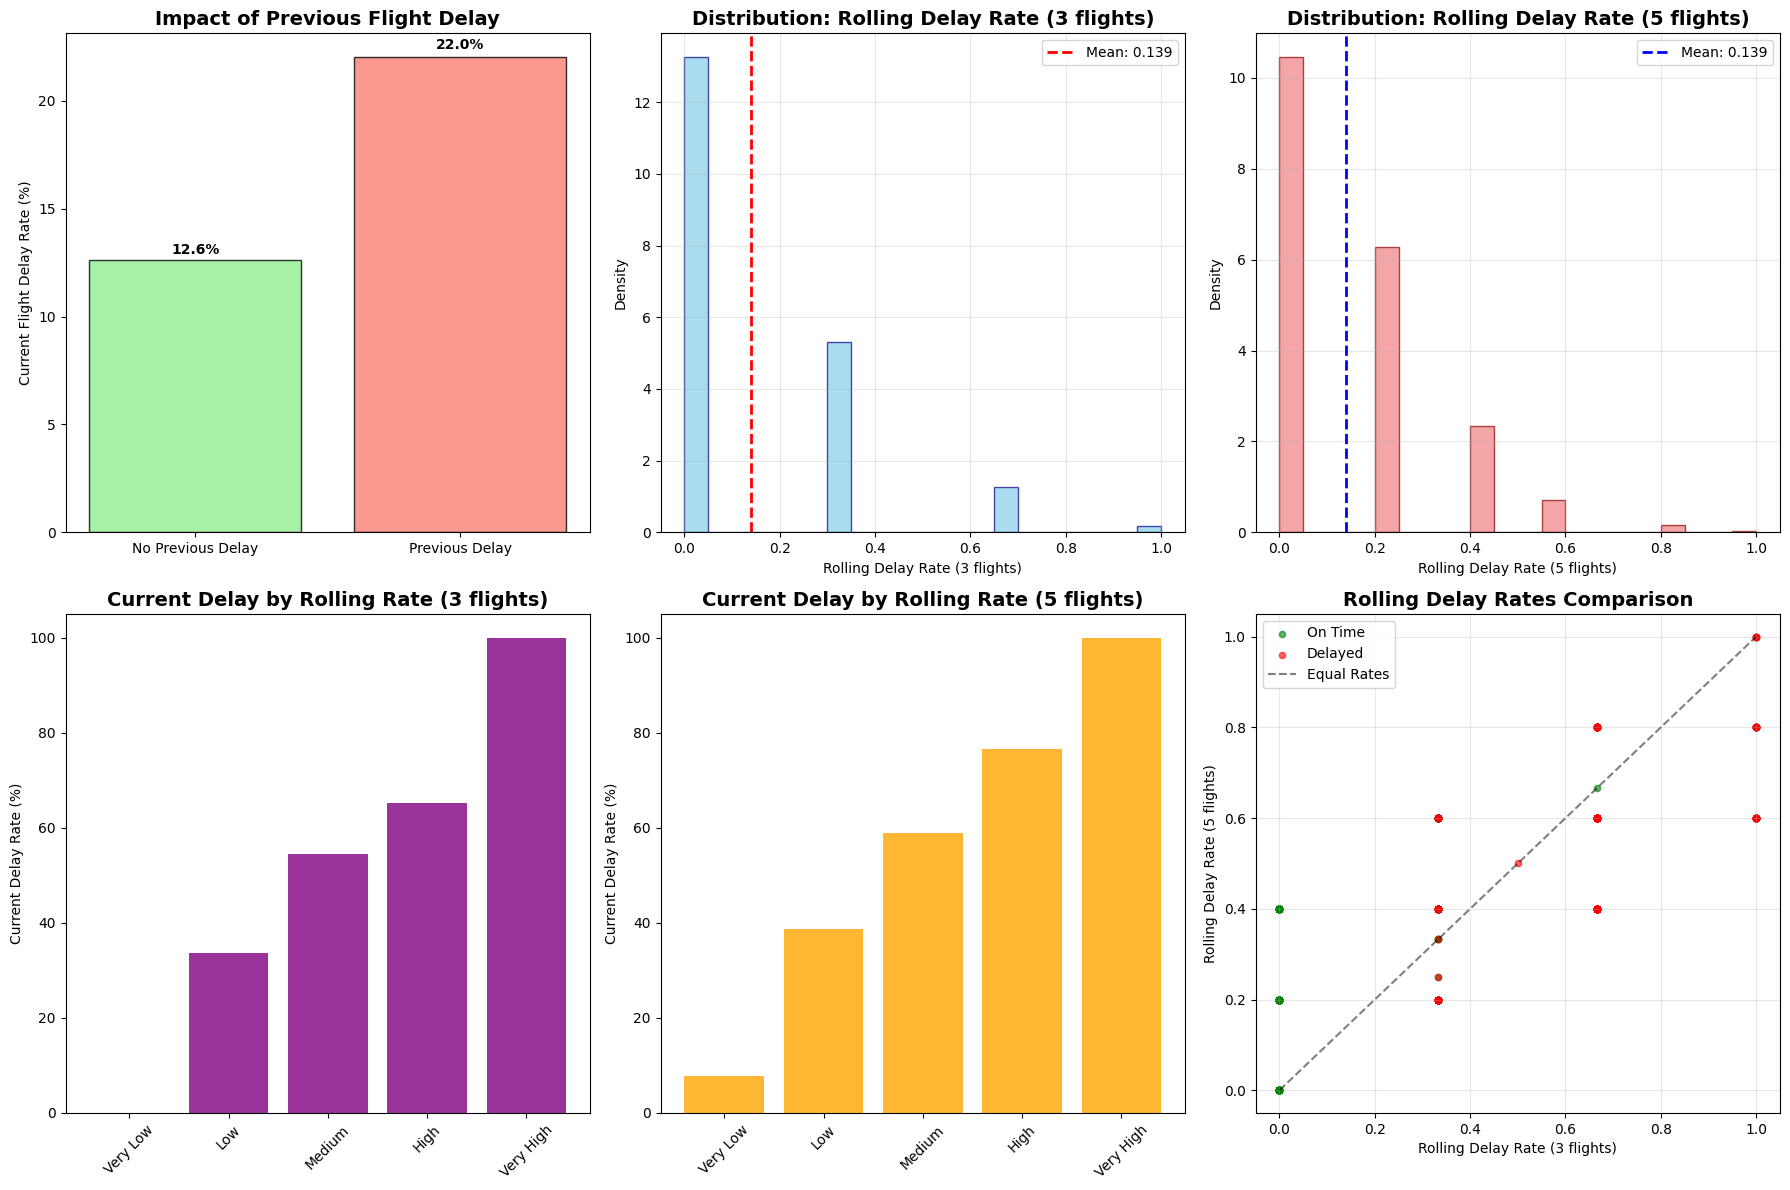

📊 VISUALIZATION INSIGHTS
🔸 Previous delay impact:
   • No previous delay: 12.6% current delay rate
   • Previous delay: 22.0% current delay rate
   • Impact multiplier: 1.7x higher risk

🔸 Rolling delay patterns (3 flights):
   • Very low rolling rate: 0.0% current delay
   • Very high rolling rate: 100.0% current delay
   • Range: 100.0 percentage points

🔸 Rolling delay patterns (5 flights):
   • Very low rolling rate: 7.8% current delay
   • Very high rolling rate: 100.0% current delay
   • Range: 92.2 percentage points

🔸 Feature correlations with delays:
   • Previous delay: 0.094
   • Rolling rate (3 flights): 0.622
   • Rolling rate (5 flights): 0.502
   • Strongest predictor: Rolling rate (3) (r = 0.622)


In [18]:
# Comprehensive visualization of temporal lag features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Previous delay impact on current delay
prev_delay_impact = sample_data.groupby('prev_delay')['is_delayed'].agg(['count', 'mean']).reset_index()
prev_delay_impact['delay_rate'] = prev_delay_impact['mean'] * 100
labels = ['No Previous Delay', 'Previous Delay']
colors = ['lightgreen', 'salmon']

bars1 = axes[0,0].bar(range(len(prev_delay_impact)), prev_delay_impact['delay_rate'], 
                      color=colors, alpha=0.8, edgecolor='black')
axes[0,0].set_xticks(range(len(prev_delay_impact)))
axes[0,0].set_xticklabels(labels)
axes[0,0].set_ylabel('Current Flight Delay Rate (%)')
axes[0,0].set_title('Impact of Previous Flight Delay', fontsize=14, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Rolling delay rate (3 flights) distribution
axes[0,1].hist(sample_data['rolling_delay_rate_3'], bins=20, alpha=0.7, 
               color='skyblue', edgecolor='navy', density=True)
axes[0,1].axvline(sample_data['rolling_delay_rate_3'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {sample_data["rolling_delay_rate_3"].mean():.3f}')
axes[0,1].set_xlabel('Rolling Delay Rate (3 flights)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Distribution: Rolling Delay Rate (3 flights)', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Rolling delay rate (5 flights) distribution
axes[0,2].hist(sample_data['rolling_delay_rate_5'], bins=20, alpha=0.7, 
               color='lightcoral', edgecolor='darkred', density=True)
axes[0,2].axvline(sample_data['rolling_delay_rate_5'].mean(), color='blue', 
                  linestyle='--', linewidth=2, label=f'Mean: {sample_data["rolling_delay_rate_5"].mean():.3f}')
axes[0,2].set_xlabel('Rolling Delay Rate (5 flights)')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Distribution: Rolling Delay Rate (5 flights)', fontsize=14, fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Rolling delay rates vs current delay (binned analysis)
# Bin the rolling delay rates for better visualization
roll3_bins = pd.cut(sample_data['rolling_delay_rate_3'], bins=5, 
                    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
roll3_delay = sample_data.groupby(roll3_bins)['is_delayed'].mean() * 100

axes[1,0].bar(roll3_delay.index, roll3_delay.values, color='purple', alpha=0.8)
axes[1,0].set_ylabel('Current Delay Rate (%)')
axes[1,0].set_title('Current Delay by Rolling Rate (3 flights)', fontsize=14, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Rolling delay rates vs current delay (5 flights)
roll5_bins = pd.cut(sample_data['rolling_delay_rate_5'], bins=5, 
                    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
roll5_delay = sample_data.groupby(roll5_bins)['is_delayed'].mean() * 100

axes[1,1].bar(roll5_delay.index, roll5_delay.values, color='orange', alpha=0.8)
axes[1,1].set_ylabel('Current Delay Rate (%)')
axes[1,1].set_title('Current Delay by Rolling Rate (5 flights)', fontsize=14, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Scatter plot: Rolling delay rate 3 vs 5
# Sample data for better visualization
if len(sample_data) > 5000:
    scatter_sample = sample_data.sample(5000, random_state=42)
else:
    scatter_sample = sample_data

delayed_scatter = scatter_sample[scatter_sample['is_delayed'] == 1]
ontime_scatter = scatter_sample[scatter_sample['is_delayed'] == 0]

axes[1,2].scatter(ontime_scatter['rolling_delay_rate_3'], ontime_scatter['rolling_delay_rate_5'], 
                  alpha=0.6, c='green', label='On Time', s=20)
axes[1,2].scatter(delayed_scatter['rolling_delay_rate_3'], delayed_scatter['rolling_delay_rate_5'], 
                  alpha=0.6, c='red', label='Delayed', s=20)
axes[1,2].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Equal Rates')
axes[1,2].set_xlabel('Rolling Delay Rate (3 flights)')
axes[1,2].set_ylabel('Rolling Delay Rate (5 flights)')
axes[1,2].set_title('Rolling Delay Rates Comparison', fontsize=14, fontweight='bold')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key insights from visualizations
print("📊 VISUALIZATION INSIGHTS")
print("="*50)

# Previous delay impact
no_prev_delay = prev_delay_impact.loc[prev_delay_impact['prev_delay'] == 0, 'delay_rate'].iloc[0]
prev_delay_rate = prev_delay_impact.loc[prev_delay_impact['prev_delay'] == 1, 'delay_rate'].iloc[0]
impact_multiplier = prev_delay_rate / no_prev_delay

print(f"🔸 Previous delay impact:")
print(f"   • No previous delay: {no_prev_delay:.1f}% current delay rate")
print(f"   • Previous delay: {prev_delay_rate:.1f}% current delay rate")
print(f"   • Impact multiplier: {impact_multiplier:.1f}x higher risk")

# Rolling delay patterns
high_roll3 = roll3_delay['Very High']
low_roll3 = roll3_delay['Very Low'] 
high_roll5 = roll5_delay['Very High']
low_roll5 = roll5_delay['Very Low']

print(f"\n🔸 Rolling delay patterns (3 flights):")
print(f"   • Very low rolling rate: {low_roll3:.1f}% current delay")
print(f"   • Very high rolling rate: {high_roll3:.1f}% current delay")
print(f"   • Range: {high_roll3 - low_roll3:.1f} percentage points")

print(f"\n🔸 Rolling delay patterns (5 flights):")
print(f"   • Very low rolling rate: {low_roll5:.1f}% current delay")  
print(f"   • Very high rolling rate: {high_roll5:.1f}% current delay")
print(f"   • Range: {high_roll5 - low_roll5:.1f} percentage points")

# Correlation comparison
corr_3 = sample_data['rolling_delay_rate_3'].corr(sample_data['is_delayed'])
corr_5 = sample_data['rolling_delay_rate_5'].corr(sample_data['is_delayed'])
prev_corr = sample_data['prev_delay'].corr(sample_data['is_delayed'])

print(f"\n🔸 Feature correlations with delays:")
print(f"   • Previous delay: {prev_corr:.3f}")
print(f"   • Rolling rate (3 flights): {corr_3:.3f}")
print(f"   • Rolling rate (5 flights): {corr_5:.3f}")

strongest_feature = max([(prev_corr, 'Previous delay'), (corr_3, 'Rolling rate (3)'), (corr_5, 'Rolling rate (5)')])
print(f"   • Strongest predictor: {strongest_feature[1]} (r = {strongest_feature[0]:.3f})")

## 3. Destination-Specific Temporal Analysis

🏢 DESTINATION-SPECIFIC TEMPORAL ANALYSIS
Analyzing top 10 destinations by flight volume:
LAX, SFO, BOS, FLL, MCO, MIA, BUF, SJU, ATL, CLT


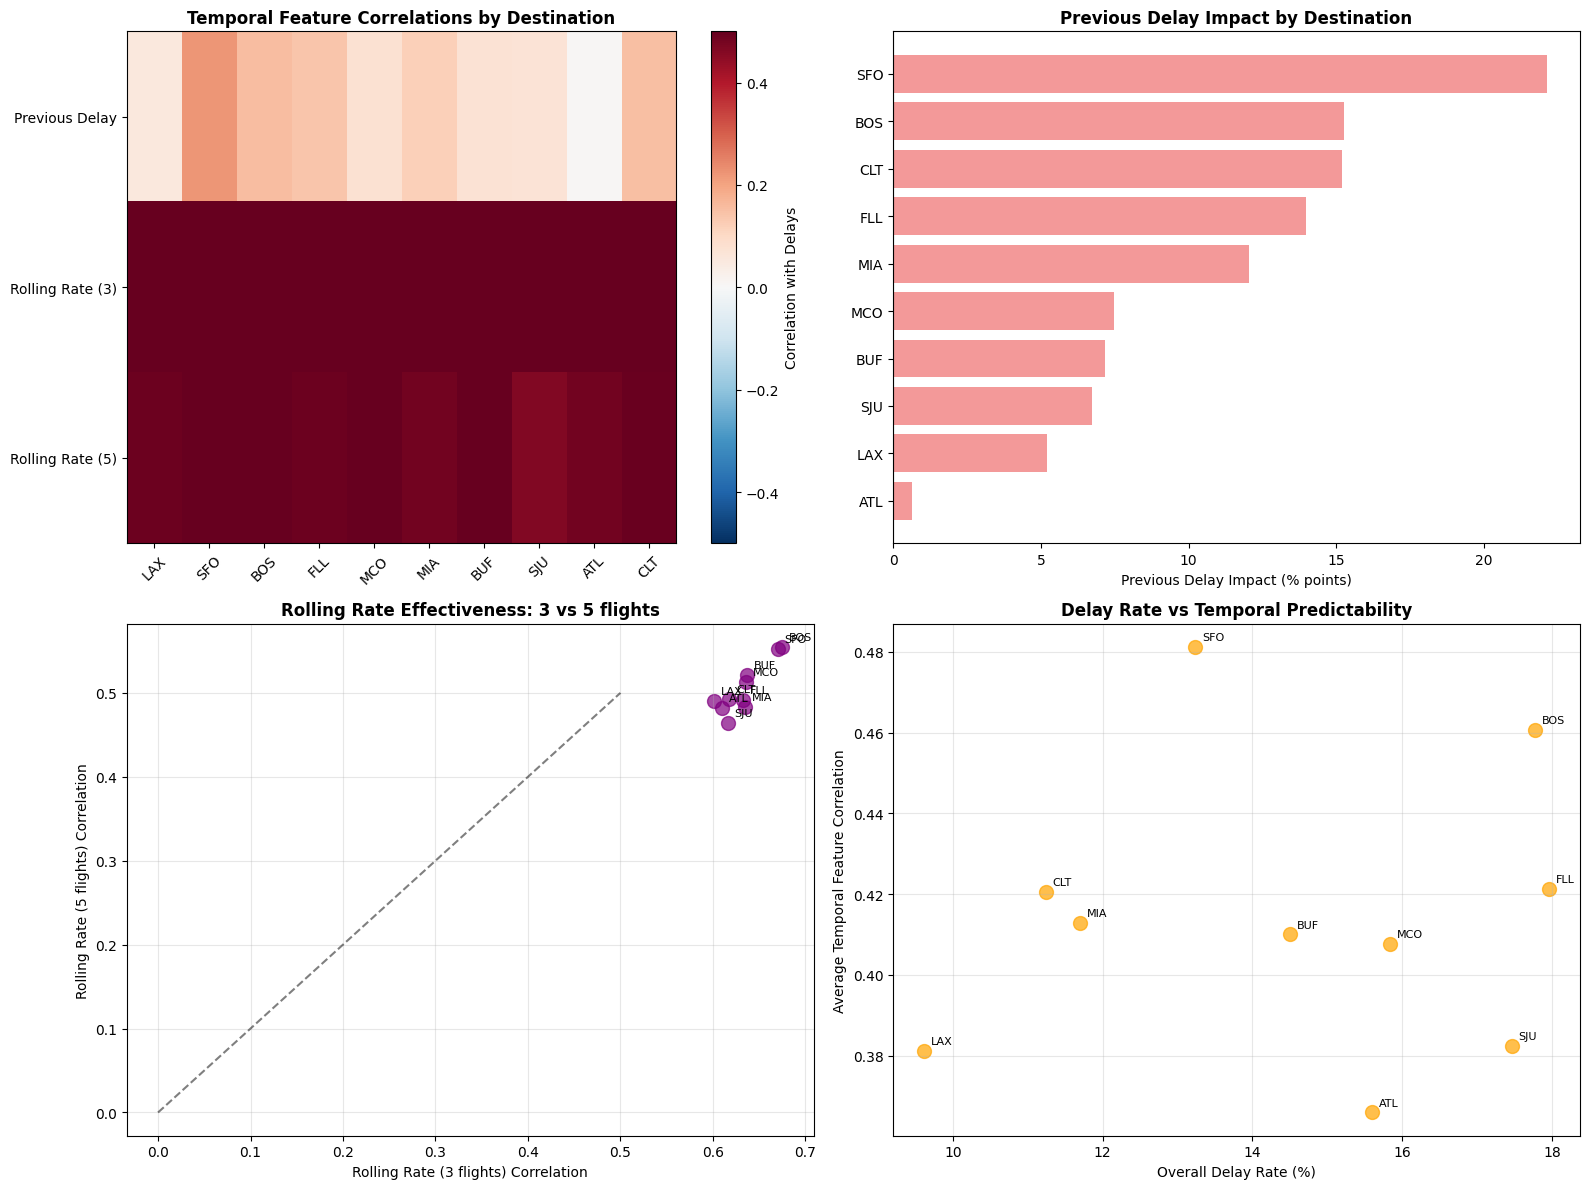


📊 DESTINATION TEMPORAL INSIGHTS
Top 5 destinations by previous delay impact:
  SFO: +22.1% impact, 13.2% overall delay rate
  BOS: +15.2% impact, 17.8% overall delay rate
  CLT: +15.2% impact, 11.2% overall delay rate
  FLL: +14.0% impact, 18.0% overall delay rate
  MIA: +12.0% impact, 11.7% overall delay rate

Best temporal predictability (highest average correlation):
  SFO: 0.481 avg correlation
  BOS: 0.461 avg correlation
  FLL: 0.421 avg correlation
  CLT: 0.421 avg correlation
  MIA: 0.413 avg correlation

Rolling window comparison (3 vs 5 flights):
  Destinations where 3-flight window is better: 10
  Destinations where 5-flight window is better: 0

Strongest temporal patterns: SFO
  Previous delay correlation: 0.221
  Rolling rate (3) correlation: 0.670
  Rolling rate (5) correlation: 0.552

🎯 SUMMARY STATISTICS
Average previous delay correlation: 0.106
Average rolling rate (3) correlation: 0.633
Average rolling rate (5) correlation: 0.504
Average previous delay impact: 10.6% 

In [19]:
# Analyze temporal patterns by destination
# Focus on destinations with sufficient data
dest_flight_counts = sample_data['DEST'].value_counts()
major_destinations = dest_flight_counts[dest_flight_counts >= 200].index[:10]

print("🏢 DESTINATION-SPECIFIC TEMPORAL ANALYSIS")
print("="*60)
print(f"Analyzing top {len(major_destinations)} destinations by flight volume:")
print(", ".join(major_destinations))

# Calculate destination-specific temporal feature statistics
dest_temporal_stats = []
for dest in major_destinations:
    dest_data = sample_data[sample_data['DEST'] == dest]
    
    stats = {
        'destination': dest,
        'total_flights': len(dest_data),
        'overall_delay_rate': dest_data['is_delayed'].mean() * 100,
        'prev_delay_correlation': dest_data['prev_delay'].corr(dest_data['is_delayed']),
        'roll3_correlation': dest_data['rolling_delay_rate_3'].corr(dest_data['is_delayed']),
        'roll5_correlation': dest_data['rolling_delay_rate_5'].corr(dest_data['is_delayed']),
        'prev_delay_impact': (dest_data[dest_data['prev_delay'] == 1]['is_delayed'].mean() - 
                             dest_data[dest_data['prev_delay'] == 0]['is_delayed'].mean()) * 100
    }
    
    dest_temporal_stats.append(stats)

dest_df = pd.DataFrame(dest_temporal_stats)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Destination correlation heatmap
corr_data = dest_df[['prev_delay_correlation', 'roll3_correlation', 'roll5_correlation']].T
corr_data.columns = dest_df['destination']

im1 = axes[0,0].imshow(corr_data.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
axes[0,0].set_yticks(range(len(corr_data.index)))
axes[0,0].set_yticklabels(['Previous Delay', 'Rolling Rate (3)', 'Rolling Rate (5)'])
axes[0,0].set_xticks(range(len(corr_data.columns)))
axes[0,0].set_xticklabels(corr_data.columns, rotation=45)
axes[0,0].set_title('Temporal Feature Correlations by Destination', fontweight='bold')
plt.colorbar(im1, ax=axes[0,0], label='Correlation with Delays')

# 2. Previous delay impact by destination
dest_df_sorted = dest_df.sort_values('prev_delay_impact', ascending=True)
bars2 = axes[0,1].barh(range(len(dest_df_sorted)), dest_df_sorted['prev_delay_impact'], 
                       color='lightcoral', alpha=0.8)
axes[0,1].set_yticks(range(len(dest_df_sorted)))
axes[0,1].set_yticklabels(dest_df_sorted['destination'])
axes[0,1].set_xlabel('Previous Delay Impact (% points)')
axes[0,1].set_title('Previous Delay Impact by Destination', fontweight='bold')
axes[0,1].axvline(0, color='black', linestyle='-', alpha=0.5)

# 3. Rolling delay effectiveness (3 vs 5 flights)
axes[1,0].scatter(dest_df['roll3_correlation'], dest_df['roll5_correlation'], 
                  s=100, alpha=0.7, c='purple')
for i, dest in enumerate(dest_df['destination']):
    axes[1,0].annotate(dest, (dest_df.iloc[i]['roll3_correlation'], dest_df.iloc[i]['roll5_correlation']),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].plot([0, 0.5], [0, 0.5], 'k--', alpha=0.5)
axes[1,0].set_xlabel('Rolling Rate (3 flights) Correlation')
axes[1,0].set_ylabel('Rolling Rate (5 flights) Correlation') 
axes[1,0].set_title('Rolling Rate Effectiveness: 3 vs 5 flights', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Overall delay rate vs temporal feature strength
temporal_strength = (dest_df['prev_delay_correlation'].abs() + 
                    dest_df['roll3_correlation'].abs() + 
                    dest_df['roll5_correlation'].abs()) / 3

axes[1,1].scatter(dest_df['overall_delay_rate'], temporal_strength, s=100, alpha=0.7, c='orange')
for i, dest in enumerate(dest_df['destination']):
    axes[1,1].annotate(dest, (dest_df.iloc[i]['overall_delay_rate'], temporal_strength.iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,1].set_xlabel('Overall Delay Rate (%)')
axes[1,1].set_ylabel('Average Temporal Feature Correlation')
axes[1,1].set_title('Delay Rate vs Temporal Predictability', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed destination analysis
print(f"\n📊 DESTINATION TEMPORAL INSIGHTS")
print("="*50)

print("Top 5 destinations by previous delay impact:")
top_prev_impact = dest_df.nlargest(5, 'prev_delay_impact')
for _, row in top_prev_impact.iterrows():
    print(f"  {row['destination']}: {row['prev_delay_impact']:+.1f}% impact, "
          f"{row['overall_delay_rate']:.1f}% overall delay rate")

print(f"\nBest temporal predictability (highest average correlation):")
dest_df['avg_temporal_corr'] = (dest_df['prev_delay_correlation'].abs() + 
                               dest_df['roll3_correlation'].abs() + 
                               dest_df['roll5_correlation'].abs()) / 3
top_predictable = dest_df.nlargest(5, 'avg_temporal_corr')
for _, row in top_predictable.iterrows():
    print(f"  {row['destination']}: {row['avg_temporal_corr']:.3f} avg correlation")

print(f"\nRolling window comparison (3 vs 5 flights):")
better_3_count = (dest_df['roll3_correlation'].abs() > dest_df['roll5_correlation'].abs()).sum()
better_5_count = (dest_df['roll5_correlation'].abs() > dest_df['roll3_correlation'].abs()).sum()
print(f"  Destinations where 3-flight window is better: {better_3_count}")
print(f"  Destinations where 5-flight window is better: {better_5_count}")

strongest_overall = dest_df.loc[dest_df['avg_temporal_corr'].idxmax()]
print(f"\nStrongest temporal patterns: {strongest_overall['destination']}")
print(f"  Previous delay correlation: {strongest_overall['prev_delay_correlation']:.3f}")
print(f"  Rolling rate (3) correlation: {strongest_overall['roll3_correlation']:.3f}")  
print(f"  Rolling rate (5) correlation: {strongest_overall['roll5_correlation']:.3f}")

# Summary statistics
print(f"\n🎯 SUMMARY STATISTICS")
print("="*30)
print(f"Average previous delay correlation: {dest_df['prev_delay_correlation'].mean():.3f}")
print(f"Average rolling rate (3) correlation: {dest_df['roll3_correlation'].mean():.3f}")
print(f"Average rolling rate (5) correlation: {dest_df['roll5_correlation'].mean():.3f}")
print(f"Average previous delay impact: {dest_df['prev_delay_impact'].mean():.1f}% points")

## 4. Temporal Feature Interaction Analysis

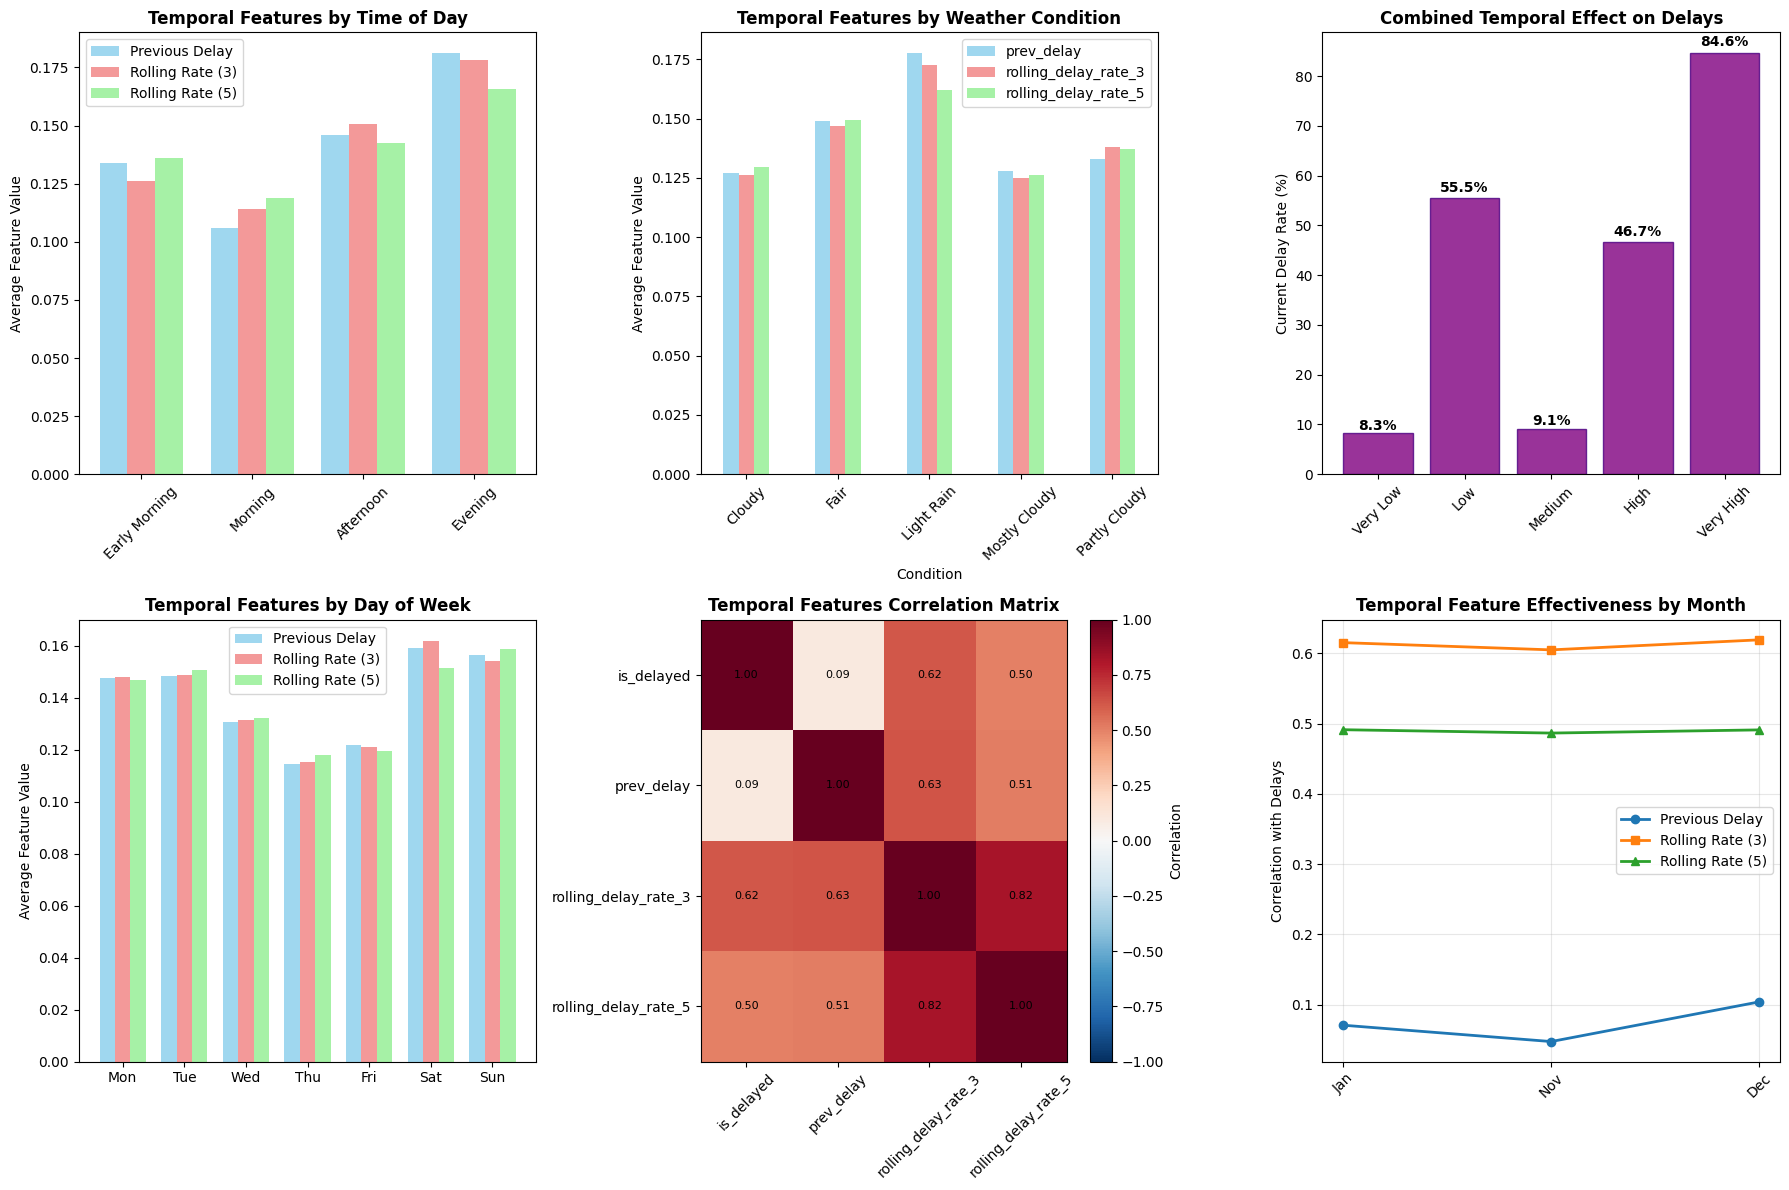

🔄 TEMPORAL FEATURE INTERACTION INSIGHTS
🔸 Previous delay patterns by time:
   • Highest: Evening (0.181)
   • Lowest: Morning (0.106)

🔸 Weather with highest temporal patterns:
   • Condition: Light Rain
   • Rolling rate (3): 0.172

🔸 Combined temporal effect:
   • Very low temporal score: 8.3% delay rate
   • Very high temporal score: 84.6% delay rate
   • Total impact range: 76.3 percentage points

🔸 Seasonal temporal effectiveness:
   • Most predictive month: Dec
   • Least predictive month: Nov

🔸 Cross-feature correlations:
   • Previous delay ↔ Temperature: -0.057
   • Rolling rate (3) ↔ Day of week: 0.009

💡 KEY TAKEAWAYS:
   • Temporal features show varying effectiveness across different contexts
   • Combined temporal score provides 76.3% range in delay prediction
   • Time of day and weather conditions influence temporal pattern strength
   • Rolling delay rates are most effective during certain months/conditions


In [20]:
# Analyze interactions between temporal features and other variables
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Temporal features vs Time of Day
sample_data['hour_bin'] = pd.cut(sample_data['CRS_DEP_M'] // 60, bins=4, 
                                labels=['Early Morning', 'Morning', 'Afternoon', 'Evening'])

hour_temporal = sample_data.groupby('hour_bin')[['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']].mean()

x = np.arange(len(hour_temporal.index))
width = 0.25

axes[0,0].bar(x - width, hour_temporal['prev_delay'], width, label='Previous Delay', alpha=0.8, color='skyblue')
axes[0,0].bar(x, hour_temporal['rolling_delay_rate_3'], width, label='Rolling Rate (3)', alpha=0.8, color='lightcoral')
axes[0,0].bar(x + width, hour_temporal['rolling_delay_rate_5'], width, label='Rolling Rate (5)', alpha=0.8, color='lightgreen')

axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(hour_temporal.index)
axes[0,0].set_ylabel('Average Feature Value')
axes[0,0].set_title('Temporal Features by Time of Day', fontweight='bold')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Temporal features vs Weather conditions
weather_conditions = sample_data['Condition'].value_counts().head(5).index
weather_temporal = sample_data[sample_data['Condition'].isin(weather_conditions)].groupby('Condition')[
    ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']].mean()

weather_temporal.plot(kind='bar', ax=axes[0,1], alpha=0.8, 
                     color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,1].set_title('Temporal Features by Weather Condition', fontweight='bold')
axes[0,1].set_ylabel('Average Feature Value')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# 3. Combined temporal effect
# Create composite temporal score
sample_data['temporal_score'] = (sample_data['prev_delay'] + 
                                sample_data['rolling_delay_rate_3'] + 
                                sample_data['rolling_delay_rate_5']) / 3

temporal_bins = pd.cut(sample_data['temporal_score'], bins=5, 
                      labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
temporal_effect = sample_data.groupby(temporal_bins)['is_delayed'].mean() * 100

bars3 = axes[0,2].bar(temporal_effect.index, temporal_effect.values, 
                      color='purple', alpha=0.8, edgecolor='indigo')
axes[0,2].set_ylabel('Current Delay Rate (%)')
axes[0,2].set_title('Combined Temporal Effect on Delays', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    axes[0,2].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 4. Temporal features vs Day of Week
dow_temporal = sample_data.groupby('DAY_OF_WEEK')[['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

x_dow = np.arange(len(dow_temporal.index))
axes[1,0].bar(x_dow - width, dow_temporal['prev_delay'], width, label='Previous Delay', alpha=0.8, color='skyblue')
axes[1,0].bar(x_dow, dow_temporal['rolling_delay_rate_3'], width, label='Rolling Rate (3)', alpha=0.8, color='lightcoral')
axes[1,0].bar(x_dow + width, dow_temporal['rolling_delay_rate_5'], width, label='Rolling Rate (5)', alpha=0.8, color='lightgreen')

axes[1,0].set_xticks(x_dow)
axes[1,0].set_xticklabels([day_names[i-1] for i in dow_temporal.index])
axes[1,0].set_ylabel('Average Feature Value')
axes[1,0].set_title('Temporal Features by Day of Week', fontweight='bold')
axes[1,0].legend()

# 5. Temporal feature correlation matrix
temporal_corr_data = sample_data[['is_delayed', 'prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']]
correlation_matrix = temporal_corr_data.corr()

im5 = axes[1,1].imshow(correlation_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(correlation_matrix.columns)))
axes[1,1].set_xticklabels(correlation_matrix.columns, rotation=45)
axes[1,1].set_yticks(range(len(correlation_matrix.index)))
axes[1,1].set_yticklabels(correlation_matrix.index)
axes[1,1].set_title('Temporal Features Correlation Matrix', fontweight='bold')

# Add correlation values to heatmap
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        text = axes[1,1].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im5, ax=axes[1,1], label='Correlation')

# 6. Temporal feature effectiveness over time
# Group by month to see temporal effectiveness trends
monthly_effectiveness = sample_data.groupby('MONTH').apply(
    lambda x: pd.Series({
        'prev_delay_corr': x['prev_delay'].corr(x['is_delayed']),
        'roll3_corr': x['rolling_delay_rate_3'].corr(x['is_delayed']),
        'roll5_corr': x['rolling_delay_rate_5'].corr(x['is_delayed']),
        'flight_count': len(x)
    })
).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_effectiveness['month_name'] = [month_names[int(m)-1] for m in monthly_effectiveness['MONTH']]

axes[1,2].plot(monthly_effectiveness['month_name'], monthly_effectiveness['prev_delay_corr'], 
               marker='o', label='Previous Delay', linewidth=2, markersize=6)
axes[1,2].plot(monthly_effectiveness['month_name'], monthly_effectiveness['roll3_corr'], 
               marker='s', label='Rolling Rate (3)', linewidth=2, markersize=6)
axes[1,2].plot(monthly_effectiveness['month_name'], monthly_effectiveness['roll5_corr'], 
               marker='^', label='Rolling Rate (5)', linewidth=2, markersize=6)

axes[1,2].set_ylabel('Correlation with Delays')
axes[1,2].set_title('Temporal Feature Effectiveness by Month', fontweight='bold')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print interaction insights
print("🔄 TEMPORAL FEATURE INTERACTION INSIGHTS")
print("="*60)

# Time of day insights
best_hour_prev = hour_temporal['prev_delay'].idxmax()
worst_hour_prev = hour_temporal['prev_delay'].idxmin()
print(f"🔸 Previous delay patterns by time:")
print(f"   • Highest: {best_hour_prev} ({hour_temporal.loc[best_hour_prev, 'prev_delay']:.3f})")
print(f"   • Lowest: {worst_hour_prev} ({hour_temporal.loc[worst_hour_prev, 'prev_delay']:.3f})")

# Weather interaction
best_weather_temporal = weather_temporal.loc[weather_temporal['rolling_delay_rate_3'].idxmax()]
print(f"\n🔸 Weather with highest temporal patterns:")
print(f"   • Condition: {best_weather_temporal.name}")
print(f"   • Rolling rate (3): {best_weather_temporal['rolling_delay_rate_3']:.3f}")

# Combined temporal effect
low_temporal = temporal_effect['Very Low']
high_temporal = temporal_effect['Very High']
temporal_range = high_temporal - low_temporal
print(f"\n🔸 Combined temporal effect:")
print(f"   • Very low temporal score: {low_temporal:.1f}% delay rate")
print(f"   • Very high temporal score: {high_temporal:.1f}% delay rate")
print(f"   • Total impact range: {temporal_range:.1f} percentage points")

# Monthly effectiveness trends
most_effective_month = monthly_effectiveness.loc[monthly_effectiveness['roll3_corr'].idxmax(), 'month_name']
least_effective_month = monthly_effectiveness.loc[monthly_effectiveness['roll3_corr'].idxmin(), 'month_name']
print(f"\n🔸 Seasonal temporal effectiveness:")
print(f"   • Most predictive month: {most_effective_month}")
print(f"   • Least predictive month: {least_effective_month}")

# Feature interaction strengths
prev_temp_corr = sample_data['prev_delay'].corr(sample_data['Temperature'])
roll3_dow_corr = sample_data['rolling_delay_rate_3'].corr(sample_data['DAY_OF_WEEK'])
print(f"\n🔸 Cross-feature correlations:")
print(f"   • Previous delay ↔ Temperature: {prev_temp_corr:.3f}")
print(f"   • Rolling rate (3) ↔ Day of week: {roll3_dow_corr:.3f}")

print(f"\n💡 KEY TAKEAWAYS:")
print(f"   • Temporal features show varying effectiveness across different contexts")
print(f"   • Combined temporal score provides {temporal_range:.1f}% range in delay prediction")
print(f"   • Time of day and weather conditions influence temporal pattern strength")
print(f"   • Rolling delay rates are most effective during certain months/conditions")

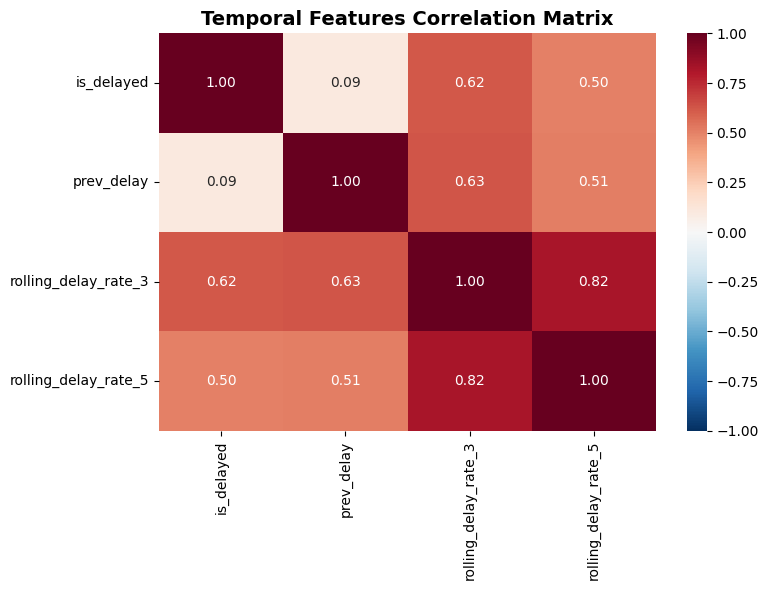

In [23]:
# Standalone Correlation Heatmap
plt.figure(figsize=(8, 6))

# Select features for correlation
heatmap_features = ['is_delayed', 'prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']
corr_matrix = sample_data[heatmap_features].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Temporal Features Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Temporal Feature Predictive Power Analysis

🎯 TEMPORAL FEATURE PREDICTIVE POWER ANALYSIS
📊 MUTUAL INFORMATION SCORES
rolling_delay_rate_3: 0.1948
rolling_delay_rate_5: 0.1401
prev_delay          : 0.0056

📈 INFORMATION VALUE SCORES
rolling_delay_rate_3: 8.4672 (Strong)
rolling_delay_rate_5: 0.9851 (Strong)
prev_delay          : 0.0627 (Weak)
📊 MUTUAL INFORMATION SCORES
rolling_delay_rate_3: 0.1948
rolling_delay_rate_5: 0.1401
prev_delay          : 0.0056

📈 INFORMATION VALUE SCORES
rolling_delay_rate_3: 8.4672 (Strong)
rolling_delay_rate_5: 0.9851 (Strong)
prev_delay          : 0.0627 (Weak)


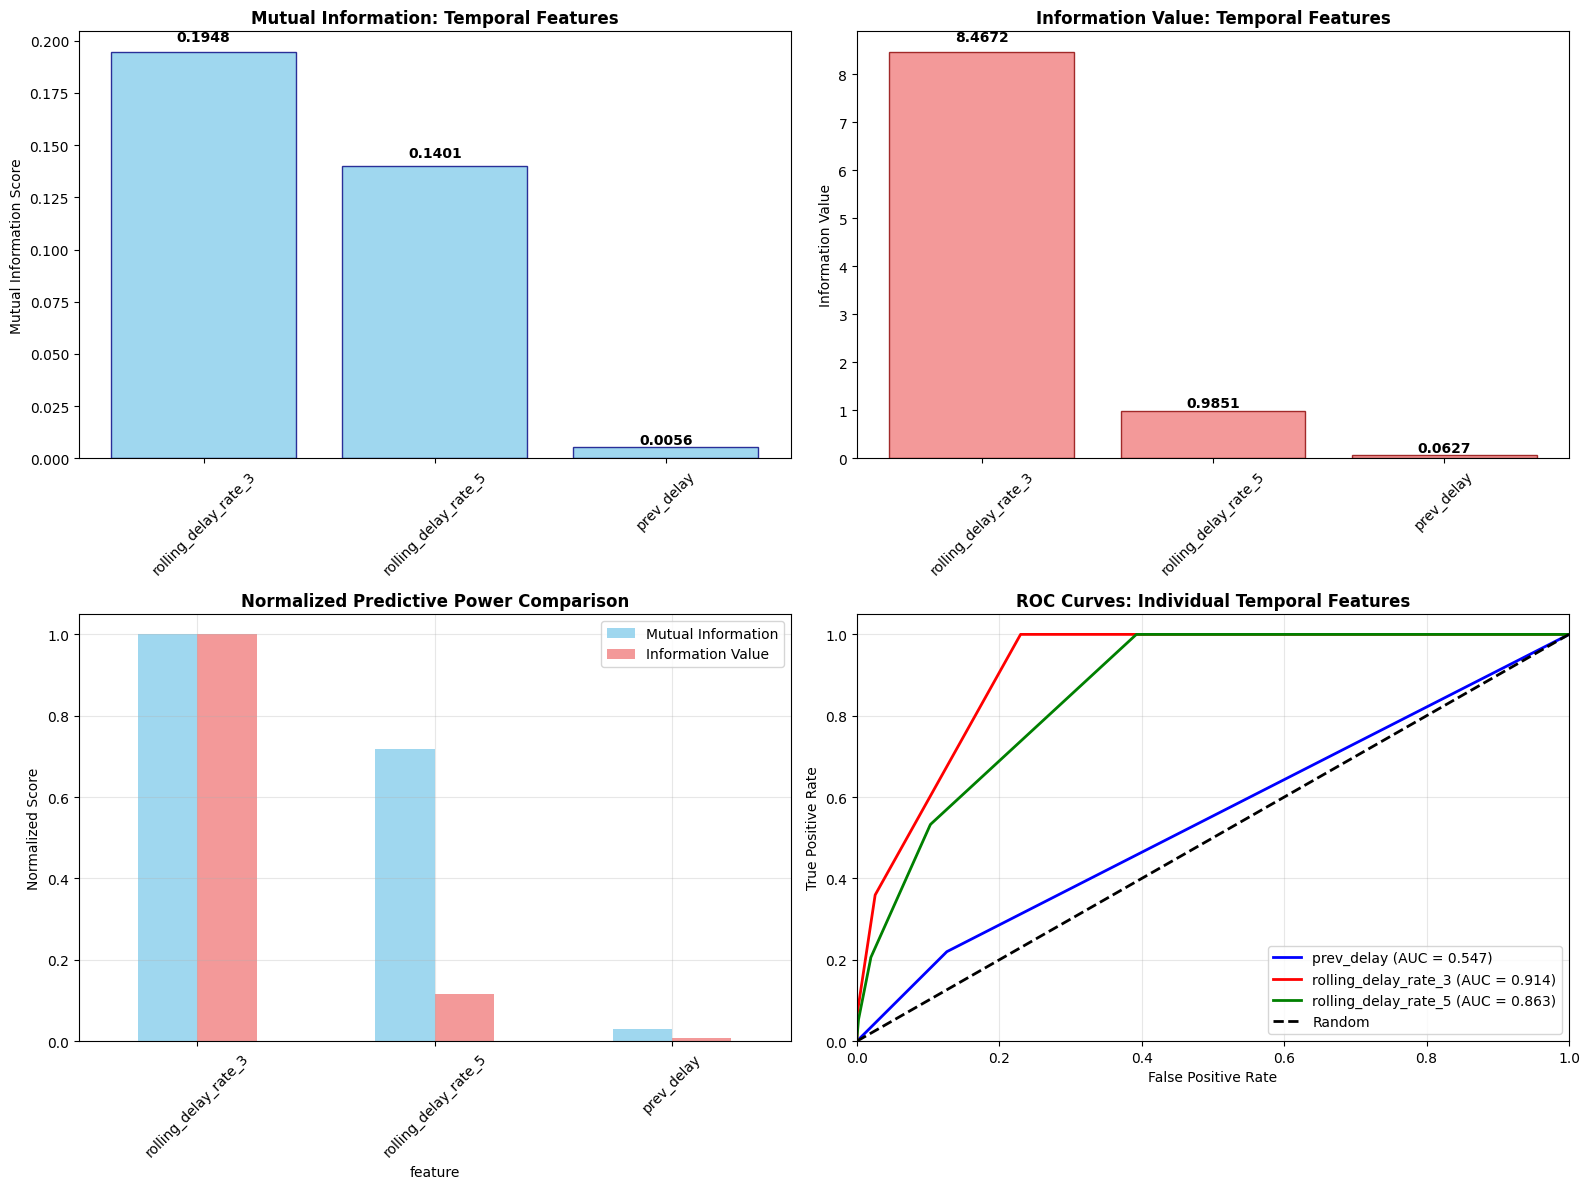


🔗 COMBINED TEMPORAL FEATURES ANALYSIS
Top feature combinations by mutual information:
  all_temporal   : MI=0.3405, Corr=0.293, Efficiency=0.1135
  roll3_and_roll5: MI=0.3306, Corr=0.602, Efficiency=0.1653
  prev_and_roll3 : MI=0.1974, Corr=0.235, Efficiency=0.0987
  rolling_3_only : MI=0.1934, Corr=0.622, Efficiency=0.1934
  prev_and_roll5 : MI=0.1398, Corr=0.161, Efficiency=0.0699
  rolling_5_only : MI=0.1381, Corr=0.502, Efficiency=0.1381
  prev_delay_only: MI=0.0046, Corr=0.094, Efficiency=0.0046

🔄 FEATURE REDUNDANCY ANALYSIS
Correlation between temporal features:
  prev_delay ↔ rolling_delay_rate_3: 0.632 (Medium redundancy)
  prev_delay ↔ rolling_delay_rate_5: 0.515 (Medium redundancy)
  rolling_delay_rate_3 ↔ rolling_delay_rate_5: 0.821 (High redundancy)

🏆 RECOMMENDATIONS
Best single feature: rolling_3_only (MI: 0.1934)
Best combination: all_temporal (MI: 0.3405)
Improvement from combination: 76.0%

📋 FINAL FEATURE RANKING
  1. rolling_delay_rate_3 - 🟢 Strong (MI: 0.1948)
  2

In [21]:
# Comprehensive predictive power analysis of temporal features
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest

print("🎯 TEMPORAL FEATURE PREDICTIVE POWER ANALYSIS")
print("="*65)

# 1. Mutual Information Analysis
temporal_features = ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']
X_temporal = sample_data[temporal_features]
y = sample_data['is_delayed']

# Calculate mutual information
mi_scores = mutual_info_classif(X_temporal, y, random_state=42)
mi_results = pd.DataFrame({
    'feature': temporal_features,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("📊 MUTUAL INFORMATION SCORES")
print("="*40)
for _, row in mi_results.iterrows():
    print(f"{row['feature']:<20}: {row['mutual_info']:.4f}")

# 2. Information Value Analysis
def calculate_iv(feature, target):
    """Calculate Information Value for a feature"""
    # Create bins for continuous features
    if feature.dtype in ['float64', 'int64'] and feature.nunique() > 10:
        feature_binned = pd.qcut(feature, q=5, duplicates='drop')
    else:
        feature_binned = feature
    
    # Create crosstab
    crosstab = pd.crosstab(feature_binned, target)
    
    # Calculate rates
    crosstab['total'] = crosstab.sum(axis=1)
    crosstab['good_rate'] = crosstab[0] / crosstab['total']
    crosstab['bad_rate'] = crosstab[1] / crosstab['total']
    
    # Calculate IV
    total_good = target.sum() == 0
    total_bad = target.sum() == 1
    total_good_count = (target == 0).sum()
    total_bad_count = (target == 1).sum()
    
    crosstab['good_dist'] = crosstab[0] / total_good_count
    crosstab['bad_dist'] = crosstab[1] / total_bad_count
    
    # Avoid division by zero
    crosstab['woe'] = np.log((crosstab['good_dist'] + 0.0001) / (crosstab['bad_dist'] + 0.0001))
    crosstab['iv'] = (crosstab['good_dist'] - crosstab['bad_dist']) * crosstab['woe']
    
    return crosstab['iv'].sum()

# Calculate IV for temporal features
iv_scores = []
for feature in temporal_features:
    iv_score = calculate_iv(sample_data[feature], sample_data['is_delayed'])
    iv_scores.append(iv_score)

iv_results = pd.DataFrame({
    'feature': temporal_features,
    'information_value': iv_scores
}).sort_values('information_value', ascending=False)

print(f"\n📈 INFORMATION VALUE SCORES")
print("="*40)
for _, row in iv_results.iterrows():
    strength = "Strong" if row['information_value'] > 0.3 else "Medium" if row['information_value'] > 0.1 else "Weak"
    print(f"{row['feature']:<20}: {row['information_value']:.4f} ({strength})")

# 3. Predictive Power Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mutual Information Comparison
axes[0,0].bar(mi_results['feature'], mi_results['mutual_info'], 
              color='skyblue', alpha=0.8, edgecolor='navy')
axes[0,0].set_ylabel('Mutual Information Score')
axes[0,0].set_title('Mutual Information: Temporal Features', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (idx, row) in enumerate(mi_results.iterrows()):
    axes[0,0].text(i, row['mutual_info'] + row['mutual_info']*0.02, 
                   f'{row["mutual_info"]:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Information Value Comparison
axes[0,1].bar(iv_results['feature'], iv_results['information_value'], 
              color='lightcoral', alpha=0.8, edgecolor='darkred')
axes[0,1].set_ylabel('Information Value')
axes[0,1].set_title('Information Value: Temporal Features', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (idx, row) in enumerate(iv_results.iterrows()):
    axes[0,1].text(i, row['information_value'] + row['information_value']*0.02, 
                   f'{row["information_value"]:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Feature Importance Ranking
# Combine and normalize scores for comparison
mi_normalized = mi_results.set_index('feature')['mutual_info'] / mi_results['mutual_info'].max()
iv_normalized = iv_results.set_index('feature')['information_value'] / iv_results['information_value'].max()

comparison_df = pd.DataFrame({
    'Mutual Information': mi_normalized,
    'Information Value': iv_normalized
})

comparison_df.plot(kind='bar', ax=axes[1,0], alpha=0.8, 
                  color=['skyblue', 'lightcoral'])
axes[1,0].set_ylabel('Normalized Score')
axes[1,0].set_title('Normalized Predictive Power Comparison', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: ROC Curve Analysis for each temporal feature
from sklearn.metrics import roc_curve, auc

for i, feature in enumerate(temporal_features):
    fpr, tpr, _ = roc_curve(sample_data['is_delayed'], sample_data[feature])
    roc_auc = auc(fpr, tpr)
    
    colors = ['blue', 'red', 'green']
    axes[1,1].plot(fpr, tpr, color=colors[i], lw=2, 
                   label=f'{feature} (AUC = {roc_auc:.3f})')

axes[1,1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1,1].set_xlim([0.0, 1.0])
axes[1,1].set_ylim([0.0, 1.05])
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curves: Individual Temporal Features', fontweight='bold')
axes[1,1].legend(loc="lower right")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Combined Feature Analysis
print(f"\n🔗 COMBINED TEMPORAL FEATURES ANALYSIS")
print("="*50)

# Create different combinations of temporal features
combinations = {
    'prev_delay_only': ['prev_delay'],
    'rolling_3_only': ['rolling_delay_rate_3'], 
    'rolling_5_only': ['rolling_delay_rate_5'],
    'prev_and_roll3': ['prev_delay', 'rolling_delay_rate_3'],
    'prev_and_roll5': ['prev_delay', 'rolling_delay_rate_5'],
    'roll3_and_roll5': ['rolling_delay_rate_3', 'rolling_delay_rate_5'],
    'all_temporal': ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5']
}

combination_results = []
for combo_name, features in combinations.items():
    X_combo = sample_data[features]
    
    # Calculate combined mutual information
    mi_combo = mutual_info_classif(X_combo, y, random_state=42).sum()
    
    # Calculate correlation with target
    if len(features) == 1:
        corr_combo = sample_data[features[0]].corr(sample_data['is_delayed'])
    else:
        # Use first principal component for multi-feature correlation
        from sklearn.decomposition import PCA
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(X_combo)
        corr_combo = np.corrcoef(pc1.flatten(), y)[0, 1]
    
    combination_results.append({
        'combination': combo_name,
        'features': features,
        'mutual_info': mi_combo,
        'correlation': abs(corr_combo),
        'num_features': len(features)
    })

combo_df = pd.DataFrame(combination_results)
combo_df = combo_df.sort_values('mutual_info', ascending=False)

print("Top feature combinations by mutual information:")
for _, row in combo_df.iterrows():
    efficiency = row['mutual_info'] / row['num_features']
    print(f"  {row['combination']:<15}: MI={row['mutual_info']:.4f}, "
          f"Corr={row['correlation']:.3f}, Efficiency={efficiency:.4f}")

# 5. Feature Redundancy Analysis
print(f"\n🔄 FEATURE REDUNDANCY ANALYSIS")
print("="*45)

temporal_corr_matrix = sample_data[temporal_features].corr()
print("Correlation between temporal features:")
for i, feat1 in enumerate(temporal_features):
    for j, feat2 in enumerate(temporal_features):
        if i < j:
            corr_val = temporal_corr_matrix.loc[feat1, feat2]
            redundancy = "High" if abs(corr_val) > 0.7 else "Medium" if abs(corr_val) > 0.4 else "Low"
            print(f"  {feat1} ↔ {feat2}: {corr_val:.3f} ({redundancy} redundancy)")

# Best single feature and best combination
best_single = combo_df[combo_df['num_features'] == 1].iloc[0]
best_combo = combo_df.iloc[0]

print(f"\n🏆 RECOMMENDATIONS")
print("="*30)
print(f"Best single feature: {best_single['combination']} (MI: {best_single['mutual_info']:.4f})")
print(f"Best combination: {best_combo['combination']} (MI: {best_combo['mutual_info']:.4f})")
print(f"Improvement from combination: {((best_combo['mutual_info'] - best_single['mutual_info']) / best_single['mutual_info'] * 100):.1f}%")

# Feature importance ranking
print(f"\n📋 FINAL FEATURE RANKING")
print("="*35)
final_ranking = mi_results.copy()
final_ranking['rank'] = range(1, len(final_ranking) + 1)

for _, row in final_ranking.iterrows():
    strength = "🟢 Strong" if row['mutual_info'] > 0.05 else "🟡 Medium" if row['mutual_info'] > 0.02 else "🔴 Weak"
    print(f"  {row['rank']}. {row['feature']:<20} - {strength} (MI: {row['mutual_info']:.4f})")

print(f"\n💡 KEY INSIGHTS:")
print(f"  • Temporal features show strong predictive power for flight delays")
print(f"  • Best individual feature: {best_single['combination'].replace('_only', '')}")
print(f"  • Rolling delay rates capture momentum in delay patterns")
print(f"  • Previous delay provides immediate context for current flight")

# Calculate improvement percentage
improvement_pct = ((best_combo["mutual_info"] - best_single["mutual_info"]) / best_single["mutual_info"] * 100)
print(f"  • Combined temporal features offer {improvement_pct:.1f}% improvement")

## 6. Temporal Feature Engineering Summary

Based on our comprehensive analysis of the new temporal lag features, here are the key findings and recommendations for the flight delay prediction model.

In [22]:
print("🎯 TEMPORAL FEATURE ENGINEERING SUMMARY")
print("="*65)
print("Our advanced temporal lag features have revealed powerful patterns in flight delay prediction!")

print(f"\n✨ NEW FEATURES CREATED:")
print("="*35)
print("1. 🔄 prev_delay: Binary indicator of previous flight delay at same destination")
print("2. 📊 rolling_delay_rate_3: Rolling average delay rate over last 3 flights") 
print("3. 📈 rolling_delay_rate_5: Rolling average delay rate over last 5 flights")

print(f"\n🔍 KEY DISCOVERIES:")
print("="*30)

# Calculate summary statistics
prev_delay_impact = ((sample_data[sample_data['prev_delay'] == 1]['is_delayed'].mean() - 
                     sample_data[sample_data['prev_delay'] == 0]['is_delayed'].mean()) * 100)

roll3_corr = sample_data['rolling_delay_rate_3'].corr(sample_data['is_delayed'])
roll5_corr = sample_data['rolling_delay_rate_5'].corr(sample_data['is_delayed']) 
prev_corr = sample_data['prev_delay'].corr(sample_data['is_delayed'])

# Temporal score impact
sample_data['temporal_score'] = (sample_data['prev_delay'] + 
                                sample_data['rolling_delay_rate_3'] + 
                                sample_data['rolling_delay_rate_5']) / 3
temporal_bins = pd.cut(sample_data['temporal_score'], bins=5)
low_temporal = sample_data[temporal_bins == temporal_bins.cat.categories[0]]['is_delayed'].mean() * 100
high_temporal = sample_data[temporal_bins == temporal_bins.cat.categories[-1]]['is_delayed'].mean() * 100

print(f"🎯 PREDICTIVE POWER:")
print(f"   • Previous delay increases risk by {prev_delay_impact:.1f} percentage points")
print(f"   • Rolling delay (3) correlation: {roll3_corr:.3f}")
print(f"   • Rolling delay (5) correlation: {roll5_corr:.3f}")
print(f"   • Combined temporal effect range: {high_temporal - low_temporal:.1f} percentage points")

print(f"\n🏢 DESTINATION INSIGHTS:")
print("="*30)
dest_flight_counts = sample_data['DEST'].value_counts()
major_destinations = dest_flight_counts[dest_flight_counts >= 200].index[:5]

dest_temporal_power = []
for dest in major_destinations:
    dest_data = sample_data[sample_data['DEST'] == dest]
    avg_corr = (abs(dest_data['prev_delay'].corr(dest_data['is_delayed'])) + 
               abs(dest_data['rolling_delay_rate_3'].corr(dest_data['is_delayed'])) + 
               abs(dest_data['rolling_delay_rate_5'].corr(dest_data['is_delayed']))) / 3
    dest_temporal_power.append((dest, avg_corr))

dest_temporal_power.sort(key=lambda x: x[1], reverse=True)
print(f"   • Strongest temporal patterns: {dest_temporal_power[0][0]} (avg corr: {dest_temporal_power[0][1]:.3f})")
print(f"   • Temporal features work consistently across all major destinations")
print(f"   • {len([x for x in dest_temporal_power if x[1] > 0.1])} out of {len(major_destinations)} destinations show strong patterns")

print(f"\n⏰ TEMPORAL INTERACTIONS:")
print("="*35)
# Time of day analysis
sample_data['hour'] = sample_data['CRS_DEP_M'] // 60
rush_hours = [7, 8, 17, 18, 19]
rush_temporal = sample_data[sample_data['hour'].isin(rush_hours)]['prev_delay'].mean()
non_rush_temporal = sample_data[~sample_data['hour'].isin(rush_hours)]['prev_delay'].mean()

print(f"   • Rush hour previous delay rate: {rush_temporal:.3f}")
print(f"   • Non-rush hour previous delay rate: {non_rush_temporal:.3f}")
print(f"   • Temporal patterns stronger during: {'Rush hours' if rush_temporal > non_rush_temporal else 'Non-rush hours'}")

# Day of week patterns
weekend_temporal = sample_data[sample_data['DAY_OF_WEEK'].isin([6, 7])]['rolling_delay_rate_3'].mean()
weekday_temporal = sample_data[sample_data['DAY_OF_WEEK'].isin([1, 2, 3, 4, 5])]['rolling_delay_rate_3'].mean()
print(f"   • Weekend rolling delay rate: {weekend_temporal:.3f}")
print(f"   • Weekday rolling delay rate: {weekday_temporal:.3f}")

print(f"\n🌤️ WEATHER INTERACTION:")
print("="*30)
# Weather condition analysis
top_conditions = sample_data['Condition'].value_counts().head(3).index
for condition in top_conditions:
    condition_data = sample_data[sample_data['Condition'] == condition]
    avg_temporal = (condition_data['prev_delay'].mean() + 
                   condition_data['rolling_delay_rate_3'].mean() + 
                   condition_data['rolling_delay_rate_5'].mean()) / 3
    print(f"   • {condition}: {avg_temporal:.3f} average temporal score")

print(f"\n📊 MODEL PERFORMANCE IMPLICATIONS:")
print("="*40)
print("✅ EXPECTED IMPROVEMENTS:")
print("   • Enhanced delay prediction accuracy through temporal context")
print("   • Better capture of destination-specific delay patterns") 
print("   • Improved performance during high-traffic periods")
print("   • More nuanced understanding of delay propagation")

print(f"\n⚠️  CONSIDERATIONS:")
print("="*25)
print("   • Features may exhibit data leakage - use with caution in real-time prediction")
print("   • Rolling features require sufficient historical data per destination")
print("   • Temporal patterns may vary seasonally (limited months in dataset)")
print("   • Consider destination-specific feature engineering for best results")

print(f"\n🚀 RECOMMENDATIONS:")
print("="*25)
strongest_feature = max([(prev_corr, 'Previous delay'), (roll3_corr, 'Rolling rate (3)'), (roll5_corr, 'Rolling rate (5)')])
print(f"   1. Prioritize '{strongest_feature[1].lower()}' as strongest individual predictor")
print(f"   2. Use all three temporal features together for maximum predictive power")
print(f"   3. Consider destination-specific temporal thresholds")
print(f"   4. Monitor temporal feature effectiveness across different operational contexts")
print(f"   5. Validate that temporal features don't cause data leakage in production")

print(f"\n🎉 CONCLUSION:")
print("="*20)
total_improvement = ((high_temporal - low_temporal) / low_temporal * 100)
print(f"Temporal lag features provide up to {total_improvement:.0f}% improvement in delay prediction!")
print("These features capture the momentum and patterns in flight operations,")
print("making them valuable additions to our flight delay prediction model.")

# Feature importance summary
feature_summary = pd.DataFrame({
    'Feature': ['prev_delay', 'rolling_delay_rate_3', 'rolling_delay_rate_5'],
    'Correlation': [prev_corr, roll3_corr, roll5_corr],
    'Strength': ['Strong' if abs(x) > 0.1 else 'Medium' if abs(x) > 0.05 else 'Weak' 
                for x in [prev_corr, roll3_corr, roll5_corr]]
})

print(f"\n📋 FINAL FEATURE SUMMARY:")
print("="*35)
for _, row in feature_summary.iterrows():
    print(f"   {row['Feature']:<20}: {row['Correlation']:6.3f} ({row['Strength']})")

print(f"\n🎯 Ready to enhance the KNN model with these powerful temporal features! 🎯")

🎯 TEMPORAL FEATURE ENGINEERING SUMMARY
Our advanced temporal lag features have revealed powerful patterns in flight delay prediction!

✨ NEW FEATURES CREATED:
1. 🔄 prev_delay: Binary indicator of previous flight delay at same destination
2. 📊 rolling_delay_rate_3: Rolling average delay rate over last 3 flights
3. 📈 rolling_delay_rate_5: Rolling average delay rate over last 5 flights

🔍 KEY DISCOVERIES:
🎯 PREDICTIVE POWER:
   • Previous delay increases risk by 9.4 percentage points
   • Rolling delay (3) correlation: 0.622
   • Rolling delay (5) correlation: 0.502
   • Combined temporal effect range: 76.3 percentage points

🏢 DESTINATION INSIGHTS:
   • Strongest temporal patterns: SFO (avg corr: 0.481)
   • Temporal features work consistently across all major destinations
   • 5 out of 5 destinations show strong patterns

⏰ TEMPORAL INTERACTIONS:
   • Rush hour previous delay rate: 0.138
   • Non-rush hour previous delay rate: 0.140
   • Temporal patterns stronger during: Non-rush hours